# TP2 · Black Friday Sales Prediction
## Análisis Exploratorio y Curación de Datos

**Mentoría · Diplomatura en Ciencias de Datos (FaMAF 2026)**

**Insumo:** dataset sintético *temporal* de Black Friday (`bf_dataset_temporal.csv.gz`).

En el TP1 trabajamos con una **foto** de un único evento de Black Friday. No había fechas, así que el
análisis era puramente transversal: mirábamos el perfil de cada cliente y cada producto para entender
la variable `Purchase`. Este dataset agrega justamente lo que allí faltaba. Ahora cada transacción trae
fecha, hora, campaña y contexto económico, y las compras se reparten a lo largo del calendario.

Ese cambio abre preguntas nuevas. En el TP1 nos preguntábamos *quién* gasta más; acá podemos
preguntarnos *cuándo* se vende más y por qué. En el TP1 describíamos la distribución de `Purchase`; acá
podemos hablar de su evolución, su tendencia y su estacionalidad. Y donde antes hacíamos una selección
preliminar de variables, ahora vamos hasta el final: curamos los problemas que encontremos, agregamos
las variables que hagan falta y dejamos un dataset curado y reproducible.

**Qué queremos lograr con este entregable:** auditar la calidad del archivo, explorar su estructura
temporal, curar de forma justificada los problemas detectados y producir
`datos/bf_dataset_temporal_curado.csv.gz`, listo para las etapas de modelado que vienen después.

**Reglas de trabajo que fija la consigna:**

1. La notebook se ejecuta de principio a fin.
2. Queda registrado el archivo usado, la cantidad de filas y columnas, el rango de fechas, la semilla y
   las decisiones de limpieza.
3. En el entregable queda solo lo relevante, y después de cada análisis escribimos una conclusión.
4. El archivo de entrada nunca se sobrescribe.

### Puntos a resolver

- **0.** Preparación del entorno y registro de los datos.
- **1.** Auditoría de calidad: estructura y granularidad, valores nulos, valores erróneos y consistencia
  temporal, outliers.
- **2.** Análisis exploratorio temporal: evolución y estacionalidad, tendencia y medias móviles,
  segmentación.
- **3.** Curación, transformación y *feature engineering*: tratamiento de faltantes e inconsistencias,
  imputación iterativa con KNN, variables de transacción, transformaciones temporales, codificación y
  escalado, reducción de dimensionalidad con PCA.
- **4.** Relaciones y dependencia temporal: correlaciones de Pearson y Spearman, autocorrelación,
  redundancia entre variables.
- **5.** Balance de la curación: qué se conservó, qué se modificó y con qué consecuencias.
- **6.** Generación del dataset curado y su diccionario de datos.

---
# 0. Preparación del entorno y registro de los datos

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)

# Semilla: fija todo lo que tenga una parte aleatoria (muestreos, imputación, PCA).
SEED = 42
np.random.seed(SEED)

# Estilo de gráficos, con el mismo criterio que usamos en el TP1.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def miles(ax, eje="y"):
    """Formatea un eje con separador de miles (12.345 en lugar de 12345)."""
    f = mticker.FuncFormatter(lambda v, p: f"{v:,.0f}")
    (ax.yaxis if eje == "y" else ax.xaxis).set_major_formatter(f)


def millones(ax, eje="y"):
    """Formatea un eje en millones (18M en lugar de 18.000.000)."""
    f = mticker.FuncFormatter(lambda v, p: f"{v / 1e6:,.0f}M")
    (ax.yaxis if eje == "y" else ax.xaxis).set_major_formatter(f)

### Paletas de color

Igual que en el TP1, cada **atributo** tiene su propia paleta y la usamos de forma consistente en toda
la notebook. La idea es que el color aporte información por sí solo:

- una paleta **secuencial** (un tono que se va oscureciendo) para las variables que tienen orden, como
  campaña, edad o antigüedad;
- una paleta **cualitativa** (colores bien distintos) para las variables sin orden, como el canal, el
  género o el tipo de ausencia de un dato;
- **colores fijos por serie** para las series temporales (ventas, transacciones, ticket, medias
  móviles), así reconocemos cada una de un gráfico al siguiente.

In [3]:
# --- Series temporales: un color fijo por serie -------------------------------
C_SALES  = "#023047"   # ventas ($)
C_TX     = "#fb8500"   # cantidad de transacciones
C_TICKET = "#8338ec"   # ticket promedio
C_MA7    = "#fb8500"   # media móvil 7d
C_MA28   = "#d62828"   # media móvil 28d
C_TREND  = "#0077b6"

# --- Campaña: secuencial azul (2022 -> 2024) ---------------------------------
PAL_CAMPAIGN = {2022: "#8ecae6", 2023: "#219ebc", 2024: "#023047"}

# --- Canal de venta: cualitativa -------------------------------------------------
PAL_CHANNEL = {"Online": "#e76f51", "Store": "#2a9d8f"}

# --- Tipo de ausencia de datos: cualitativa ------------------------------------
PAL_NULL = {"Estructural": "#8d99ae", "MCAR": "#457b9d", "MAR": "#e76f51", "Completa": "#adb5bd"}

# --- Reutilizadas del TP1 -----------------------------------------------------
PAL_GENDER = {"M": "#078700", "F": "#66FF5E"}
PAL_AGE = {"0-17": "#90fbf6", "18-25": "#7fe4df", "26-35": "#60c6c1", "36-45": "#44a9a4",
           "46-50": "#2a8782", "51-55": "#176460", "55+": "#0b4946"}
PAL_CITY = {"A": "#e6a6e0", "B": "#a84fa0", "C": "#3d0a38"}
PAL_STAY = {"0": "#ff8989", "1": "#d15555", "2": "#9d2a2a", "3": "#781414", "4+": "#510606"}

# --- Días de la semana: fin de semana resaltado -------------------------------
DOW_ORDER = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
PAL_DOW = {d: ("#e63946" if d in ("Sáb", "Dom") else "#457b9d") for d in DOW_ORDER}
MES_ORDER = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

AGE_ORDER = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]

## 0.1 Carga del archivo y registro de los datos

El único insumo del trabajo es `bf_dataset_temporal.csv.gz`. Para que la notebook corra en cualquier
lado (una computadora con el repo clonado, pero también un Colab recién abierto sin nada descargado)
probamos varias fuentes en orden y nos quedamos con la primera que funcione:

1. el archivo ya presente en alguna de las rutas habituales del repo (`datos/`, la carpeta actual);
2. la copia comprimida publicada en el **raw de GitHub** del repositorio del grupo;
3. **Google Drive** del grupo, bajando el archivo con `gdown` (que resuelve solo la pantalla de
   confirmación que Drive intercala para archivos grandes);
4. como último recurso, la subida manual del archivo en Colab.

`Purchase_Date` se interpreta como fecha desde la lectura.

In [4]:
import os

ARCHIVO_NOMBRE = "bf_dataset_temporal.csv.gz"
DRIVE_FILE_ID  = "1SIhxuMeAGLLYv3Pgz4mFE_LtywgM6QGl"   # copia sin comprimir en el Drive del grupo
DRIVE_NOMBRE   = "bf_dataset_temporal.csv"
URL_RAW_GZ     = ("https://raw.githubusercontent.com/dyvanoff/"
                  "blackfriday_sales_prediction/main/datos/bf_dataset_temporal.csv.gz")

RUTAS_LOCALES = [
    f"datos/{ARCHIVO_NOMBRE}",
    ARCHIVO_NOMBRE,
    f"blackfriday_sales_prediction/datos/{ARCHIVO_NOMBRE}",
    f"/content/drive/MyDrive/{ARCHIVO_NOMBRE}",
    f"/content/drive/MyDrive/{DRIVE_NOMBRE}",
]


def _leer(ruta):
    return pd.read_csv(ruta, parse_dates=["Purchase_Date"], compression="infer")


def cargar_dataset():
    """Devuelve (DataFrame, texto que describe de dónde salió)."""
    # (1) archivo ya disponible en alguna ruta conocida
    for ruta in RUTAS_LOCALES:
        if os.path.exists(ruta):
            return _leer(ruta), f"archivo local: {ruta}"

    # (2) raw de GitHub
    try:
        datos = _leer(URL_RAW_GZ)
        return datos, f"raw de GitHub: {URL_RAW_GZ}"
    except Exception as e:
        print(f"  raw de GitHub no disponible ({type(e).__name__})")

    # (3) Google Drive con gdown
    try:
        try:
            import gdown
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown
        destino = DRIVE_NOMBRE
        if not os.path.exists(destino):
            print(f"Descargando {destino} desde Google Drive...")
            gdown.download(id=DRIVE_FILE_ID, output=destino, quiet=False)
        return _leer(destino), f"Google Drive (id {DRIVE_FILE_ID})"
    except Exception as e:
        print(f"  Google Drive no disponible ({type(e).__name__})")

    # (4) subida manual en Colab
    try:
        from google.colab import files
        print("Subí el archivo bf_dataset_temporal.csv(.gz):")
        subido = files.upload()
        nombre = list(subido.keys())[0]
        return _leer(nombre), f"subida manual: {nombre}"
    except Exception as e:
        raise RuntimeError(
            "No se pudo cargar el dataset por ninguna vía. "
            f"Descargalo a mano y volvé a ejecutar esta celda. Detalle: {e}"
        )


df, ORIGEN = cargar_dataset()
print(f"Cargado desde {ORIGEN}")
print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas")

Cargado desde archivo local: datos/bf_dataset_temporal.csv.gz
1,650,204 filas x 27 columnas


In [5]:
# Columnas auxiliares de calendario. Sirven solo para el análisis y NO se exportan al dataset final.
df["Purchase_Month"] = df["Purchase_Date"].dt.to_period("M")
df["DOW"] = df["Purchase_Date"].dt.dayofweek            # 0 = lunes
df["DOW_name"] = df["DOW"].map(dict(enumerate(DOW_ORDER)))
df["Month_name"] = df["Purchase_Date"].dt.month.map(dict(enumerate(MES_ORDER, start=1)))
df["Day_of_year"] = df["Purchase_Date"].dt.dayofyear

COLS_CALENDARIO = ["Purchase_Month", "DOW", "DOW_name", "Month_name", "Day_of_year"]

n_filas, n_cols = df.shape
n_cols_orig = n_cols - len(COLS_CALENDARIO)
rango = (df["Purchase_Date"].min(), df["Purchase_Date"].max())
n_dias = df["Purchase_Date"].nunique()
calendario_completo = pd.date_range(rango[0], rango[1], freq="D")

print("=" * 64)
print(" REGISTRO DE LOS DATOS")
print("=" * 64)
print(f" Archivo de entrada .......... {ARCHIVO_NOMBRE}")
print(f" Origen efectivo ............ {ORIGEN}")
print(f" Filas x columnas ........... {n_filas:,} x {n_cols_orig}"
      f"  (+{len(COLS_CALENDARIO)} auxiliares de calendario en memoria)")
print(f" Rango de fechas ............ {rango[0].date()}  a  {rango[1].date()}")
print(f" Días del calendario ........ {len(calendario_completo):,}")
print(f" Días con al menos 1 compra . {n_dias:,}")
print(f" Campañas (Campaign_Year) ... {sorted(df['Campaign_Year'].unique())}")
print(f" Clientes únicos (User_ID) .. {df['User_ID'].nunique():,}")
print(f" Productos únicos ........... {df['Product_ID'].nunique():,}")
print(f" Semilla global (SEED) ...... {SEED}")
print("=" * 64)

 REGISTRO DE LOS DATOS
 Archivo de entrada .......... bf_dataset_temporal.csv.gz
 Origen efectivo ............ archivo local: datos/bf_dataset_temporal.csv.gz
 Filas x columnas ........... 1,650,204 x 27  (+5 auxiliares de calendario en memoria)
 Rango de fechas ............ 2022-01-01  a  2024-12-31
 Días del calendario ........ 1,096
 Días con al menos 1 compra . 1,096
 Campañas (Campaign_Year) ... [2022, 2023, 2024]
 Clientes únicos (User_ID) .. 5,891
 Productos únicos ........... 3,631
 Semilla global (SEED) ...... 42


In [6]:
df.head()

,Transaction_ID,User_ID,Product_ID,Purchase_Date,Transaction_Hour,Campaign_Year,Days_To_Black_Friday,Is_Weekend,Sales_Channel,CPI_Index,Monthly_Inflation_Rate,Consumer_Confidence_Index,Retail_Activity_Index,Retail_Activity_MoM,Category_Activity_Index,Category_Activity_MoM,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Transaction_Satisfaction_Score,Purchase,Purchase_Month,DOW,DOW_name,Month_name,Day_of_year
0,BF2022_0066863,1004238,P0095642,2022-01-01,0,2022,-328,1,Online,100.679,0.679,101.440,94.000,-12.460,105.912,-1.027,M,36-45,16,B,3,0,5,NaN,NaN,4.784,5040,2022-01,5,Sáb,Ene,1
1,BF2022_0069738,1004670,P00084042,2022-01-01,0,2022,-328,1,Online,NaN,0.679,NaN,94.000,-12.460,99.709,0.865,M,36-45,5,C,2,0,12,14.000,NaN,7.178,1165,2022-01,5,Sáb,Ene,1
2,BF2022_0306749,1005275,P00345842,2022-01-01,0,2022,-328,1,Online,NaN,0.679,101.440,94.000,-12.460,101.733,1.662,M,26-35,17,A,4+,0,2,8.000,14.000,5.003,9500,2022-01,5,Sáb,Ene,1
3,BF2022_0328420,1002592,P00317342,2022-01-01,0,2022,-328,1,Online,100.679,0.679,101.440,94.000,-12.460,95.430,-1.953,M,51-55,7,B,1,1,8,16.000,NaN,4.526,4110,2022-01,5,Sáb,Ene,1
4,BF2022_0339680,1004277,P00301542,2022-01-01,0,2022,-328,1,Online,NaN,0.679,101.440,94.000,-12.460,101.775,1.508,M,36-45,16,A,0,0,16,NaN,NaN,5.672,7629,2022-01,5,Sáb,Ene,1


In [7]:
# ¿Cómo se reparte el dataset entre las tres campañas?
por_campania = df.groupby("Campaign_Year").agg(
    transacciones=("Transaction_ID", "size"),
    clientes=("User_ID", "nunique"),
    productos=("Product_ID", "nunique"),
    purchase_medio=("Purchase", "mean"),
)
por_campania

,transacciones,clientes,productos,purchase_medio
Campaign_Year,,,,
2022,550068,5891,3631,"9,644.295"
2023,550068,5891,3631,"10,558.095"
2024,550068,5891,3631,"11,879.436"


**Conclusión (0.1).** El archivo llegó bien y quedó registrado de dónde salió, cuántas filas y columnas
tiene, qué rango de fechas cubre y con qué semilla trabajamos. La serie de días es **continua**: hay
tantos días con compras como días en el calendario, sin ningún hueco.

Aparecen tres bloques de información que el TP1 no tenía:

- **Temporal y de evento:** `Purchase_Date`, `Transaction_Hour`, `Campaign_Year`,
  `Days_To_Black_Friday`, `Is_Weekend`.
- **Contexto macroeconómico y de rubro:** `CPI_Index`, `Monthly_Inflation_Rate`,
  `Consumer_Confidence_Index`, `Retail_Activity_Index` y su variación mensual, `Category_Activity_Index`
  y su variación mensual.
- **De la transacción:** `Sales_Channel`, `Transaction_Satisfaction_Score`, más la `Purchase` y las
  variables demográficas que ya conocíamos.

La tabla por campaña muestra algo importante para leer todo lo que sigue: las tres campañas tienen
**exactamente la misma cantidad de transacciones**, los **mismos clientes** y los **mismos productos**
(y ese tamaño coincide con el del dataset del TP1). El `purchase_medio`, en cambio, sube campaña a
campaña. La lectura natural es que el generador sintético tomó la base de compras del TP1, la repitió
una vez por año, la repartió en el calendario y le volvió a poner precio siguiendo la inflación.

---
# 1. Auditoría, calidad y trazabilidad

Antes de tocar nada, revisamos en qué estado llega el archivo. En esta sección **solo diagnosticamos**:
miramos la estructura, contamos los nulos, chequeamos que los valores tengan sentido y buscamos
outliers. Las correcciones vienen después, en la sección 3.

## 1.a Estructura y granularidad

Queremos responder tres cosas: cuál es la unidad de observación (qué representa una fila), si los tipos
y las cardinalidades son los esperados, y si hay filas repetidas que en realidad describan el mismo
hecho.

In [8]:
info = pd.DataFrame({
    "tipo_pandas": df.dtypes.astype(str),
    "nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2),
    "cardinalidad": df.nunique(),
    "ejemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
}).loc[[c for c in df.columns if c not in ("Purchase_Month", "DOW", "DOW_name", "Month_name", "Day_of_year")]]
info

,tipo_pandas,nulos,% nulos,cardinalidad,ejemplo
Transaction_ID,object,0,0.000,1650204,BF2022_0066863
User_ID,int64,0,0.000,5891,1004238
Product_ID,object,0,0.000,3631,P0095642
Purchase_Date,datetime64[ns],0,0.000,1096,2022-01-01 00:00:00
Transaction_Hour,int64,0,0.000,24,0
Campaign_Year,int64,0,0.000,3,2022
Days_To_Black_Friday,int64,0,0.000,371,-328
Is_Weekend,int64,0,0.000,2,1
Sales_Channel,object,0,0.000,2,Online
CPI_Index,float64,529698,32.100,36,100.679


In [9]:
# --- Unidad de observación --------------------------------------------------
print("Transaction_ID es único por fila:",
      df["Transaction_ID"].is_unique, f"({df['Transaction_ID'].nunique():,} valores / {len(df):,} filas)")
print("Formato de Transaction_ID:", df["Transaction_ID"].iloc[0],
      "-> prefijo 'BF' + año de campaña + secuencia")
print()

# --- Continuidad diaria ----------------------------------------------------
calendario = pd.date_range(rango[0], rango[1], freq="D")
faltan_dias = calendario.difference(df["Purchase_Date"].unique())
print(f"Días en el rango .............. {len(calendario):,}")
print(f"Días sin ninguna transacción . {len(faltan_dias)}  ->  serie diaria CONTINUA, sin huecos")
print()

# --- Transacciones por cliente y por producto ----------------------------
tx_cli = df.groupby("User_ID").size()
tx_prod = df.groupby("Product_ID").size()
print(f"Transacciones por cliente : min {tx_cli.min()} | mediana {tx_cli.median():.0f} | max {tx_cli.max()}")
print(f"Transacciones por producto: min {tx_prod.min()} | mediana {tx_prod.median():.0f} | max {tx_prod.max()}")

Transaction_ID es único por fila: True (1,650,204 valores / 1,650,204 filas)
Formato de Transaction_ID: BF2022_0066863 -> prefijo 'BF' + año de campaña + secuencia

Días en el rango .............. 1,096
Días sin ninguna transacción . 0  ->  serie diaria CONTINUA, sin huecos

Transacciones por cliente : min 18 | mediana 162 | max 3078
Transacciones por producto: min 3 | mediana 213 | max 5640


### ¿Por qué repetir un `User_ID` o un `Product_ID` no es, por sí solo, un duplicado?

Como ya vimos en el TP1, cada fila no es un cliente ni un producto: es **una compra** (un cliente
compró un producto, un día, a una hora, por un monto). Por eso hay muchas más filas que clientes.
`Transaction_ID` es la clave que identifica esa compra de forma única.

`User_ID` y `Product_ID` son **claves de dimensión**, no de la tabla de compras:

- El dataset es un **panel**: cada cliente aparece muchas veces porque compró muchas veces, y eso es
  justamente la información que nos interesa.
- Cada producto se vende cientos de veces. Que se repita `Product_ID` es lo esperable.
- Un cliente puede incluso comprar **el mismo producto** más de una vez, en fechas o campañas
  distintas. Siguen siendo compras diferentes.

Una fila es un duplicado solo si **describe dos veces el mismo hecho**. Para detectar eso hay que mirar
una **clave de negocio** (una combinación de columnas que debería ser única), no una clave de dimensión
suelta.

In [10]:
# --- Duplicados exactos ----------------------------------------------------
dup_exactos = df.drop(columns=["Purchase_Month", "DOW", "DOW_name", "Month_name", "Day_of_year"]).duplicated().sum()

# --- Duplicados por clave de negocio -------------------------------------
# Un mismo cliente comprando el mismo producto, el mismo día y a la misma hora,
# sería con altísima probabilidad la misma compra cargada dos veces.
clave_negocio = ["User_ID", "Product_ID", "Purchase_Date", "Transaction_Hour"]
dup_clave = df.duplicated(subset=clave_negocio).sum()

# Clave más laxa: mismo cliente + producto dentro de la misma campaña
dup_cli_prod_anio = df.duplicated(subset=["User_ID", "Product_ID", "Campaign_Year"]).sum()

print(f"Duplicados EXACTOS (todas las columnas) .................... {dup_exactos}")
print(f"Duplicados por clave de negocio {clave_negocio} ... {dup_clave}")
print(f"Repeticiones (User_ID, Product_ID, Campaign_Year) .......... {dup_cli_prod_anio:,}"
      f"  ({dup_cli_prod_anio / len(df) * 100:.1f}% de las filas)")

Duplicados EXACTOS (todas las columnas) .................... 0
Duplicados por clave de negocio ['User_ID', 'Product_ID', 'Purchase_Date', 'Transaction_Hour'] ... 0
Repeticiones (User_ID, Product_ID, Campaign_Year) .......... 0  (0.0% de las filas)


**Conclusión (1.a).**

- **Granularidad:** una fila es una transacción, y `Transaction_ID` es la clave primaria (un valor por
  fila).
- **Tipos:** tenemos identificadores (`Transaction_ID`, `User_ID`, `Product_ID`), categóricas normales
  (`Gender`, `Age`, `City_Category`, `Stay_In_Current_City_Years`, `Sales_Channel`), categóricas
  enmascaradas con números (`Occupation`, `Product_Category_*`), binarias (`Marital_Status`,
  `Is_Weekend`), fecha y hora (`Purchase_Date`, `Transaction_Hour`) y numéricas continuas (los
  indicadores económicos, `Transaction_Satisfaction_Score` y `Purchase`).
- **Rango y continuidad:** los días del rango son consecutivos y **ninguno queda vacío**. Es una serie
  temporal regular, apta para medias móviles y análisis de estacionalidad.
- **Duplicados:** **cero** duplicados exactos y **cero** por la clave de negocio (cliente, producto,
  fecha y hora). Las filas que repiten la terna (cliente, producto, campaña) **no son duplicados**: son
  el mismo cliente comprando el mismo producto en fechas distintas del año, algo coherente con un panel.
  No hay nada que deduplicar.

## 1.b Valores nulos

Acá calculamos cuántos nulos hay en cada variable, vemos cómo se reparten y decidimos para cuáles va a
hacer falta pensar una estrategia de imputación.

Antes de seguir conviene fijar tres términos que vamos a usar todo el tiempo para describir **por qué**
falta un dato:

- **MCAR** (*Missing Completely At Random*, "falta completamente al azar"): la probabilidad de que el
  dato falte no depende de nada, ni de la propia variable ni del resto. Los faltantes son una muestra
  aleatoria del total.
- **MAR** (*Missing At Random*, "falta al azar condicional"): la probabilidad de que falte depende de
  **otras** variables observadas, pero no del valor que falta en sí. Por ejemplo, si un puntaje falta
  más en el canal online que en el físico.
- **MNAR** (*Missing Not At Random*, "falta no al azar"): la probabilidad de que falte depende del
  **propio valor** que no vemos. Es el caso más difícil y no lo vamos a encontrar acá, pero lo
  nombramos para completar el cuadro.

A esto le sumamos un cuarto caso que no es estadístico sino de diseño: la ausencia **estructural**,
cuando el dato "no aplica" (un producto que simplemente no tiene una tercera categoría).

In [11]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
tab_nulos = pd.DataFrame({
    "nulos": nulos,
    "% del total": (nulos / len(df) * 100).round(2),
})
tab_nulos

,nulos,% del total
Product_Category_3,1149741,69.670
CPI_Index,529698,32.100
Product_Category_2,520914,31.570
Consumer_Confidence_Index,327879,19.870
Transaction_Satisfaction_Score,125314,7.590


In [12]:
# --- ¿Cómo se distribuye la ausencia? --------------------------------------
vars_nulas = tab_nulos.index.tolist()

def perfil_faltantes(col, by):
    return df.assign(_na=df[col].isna()).groupby(by)["_na"].mean().mul(100).round(1)

print(">>> % de nulos por CAMPAÑA")
display(pd.DataFrame({c: perfil_faltantes(c, "Campaign_Year") for c in vars_nulas}))

print(">>> % de nulos por CANAL de venta")
display(pd.DataFrame({c: perfil_faltantes(c, "Sales_Channel") for c in vars_nulas}))

print(">>> % de nulos de Transaction_Satisfaction_Score por FRANJA HORARIA")
franja = pd.cut(df["Transaction_Hour"], [-1, 5, 11, 17, 23],
                labels=["madrugada (0-5)", "mañana (6-11)", "tarde (12-17)", "noche (18-23)"])
display(df.assign(_na=df["Transaction_Satisfaction_Score"].isna()).groupby(franja)["_na"].mean().mul(100).round(1))

>>> % de nulos por CAMPAÑA


,Product_Category_3,CPI_Index,Product_Category_2,Consumer_Confidence_Index,Transaction_Satisfaction_Score
Campaign_Year,,,,,
2022,69.700,32.100,31.600,19.900,7.600
2023,69.700,32.100,31.600,19.900,7.600
2024,69.700,32.100,31.600,19.900,7.600


>>> % de nulos por CANAL de venta


,Product_Category_3,CPI_Index,Product_Category_2,Consumer_Confidence_Index,Transaction_Satisfaction_Score
Sales_Channel,,,,,
Online,69.700,32.100,31.500,19.900,10.800
Store,69.700,32.100,31.600,19.900,5.700


>>> % de nulos de Transaction_Satisfaction_Score por FRANJA HORARIA


Transaction_Hour
madrugada (0-5)   10.100
mañana (6-11)      7.800
tarde (12-17)      6.400
noche (18-23)      8.800
Name: _na, dtype: float64

In [13]:
# --- ¿El nulo de los indicadores económicos es recuperable? ----------------
# Los indicadores macro son un valor por mes: si en un mes hay filas con dato,
# el nulo de otra fila del mismo mes se puede reconstruir.
chequeo_macro = df.groupby("Purchase_Month").agg(
    filas=("CPI_Index", "size"),
    cpi_no_nulos=("CPI_Index", "count"),
    cpi_valores_distintos=("CPI_Index", "nunique"),
    cci_no_nulos=("Consumer_Confidence_Index", "count"),
    cci_valores_distintos=("Consumer_Confidence_Index", "nunique"),
)
print("¿Algún mes sin NINGÚN valor de CPI?           ", (chequeo_macro["cpi_no_nulos"] == 0).any())
print("¿Algún mes sin NINGÚN valor de Confidence?    ", (chequeo_macro["cci_no_nulos"] == 0).any())
print("Máximo de valores DISTINTOS de CPI en un mes: ", int(chequeo_macro["cpi_valores_distintos"].max()),
      " (1 = el indicador es constante dentro del mes)")
chequeo_macro.head(6)

¿Algún mes sin NINGÚN valor de CPI?            False
¿Algún mes sin NINGÚN valor de Confidence?     False
Máximo de valores DISTINTOS de CPI en un mes:  1  (1 = el indicador es constante dentro del mes)


,filas,cpi_no_nulos,cpi_valores_distintos,cci_no_nulos,cci_valores_distintos
Purchase_Month,,,,,
2022-01,32107,21801,1,25728,1
2022-02,26849,18231,1,21515,1
2022-03,33462,22721,1,26814,1
2022-04,33691,22877,1,26997,1
2022-05,36185,24570,1,28996,1
2022-06,35048,23798,1,28084,1


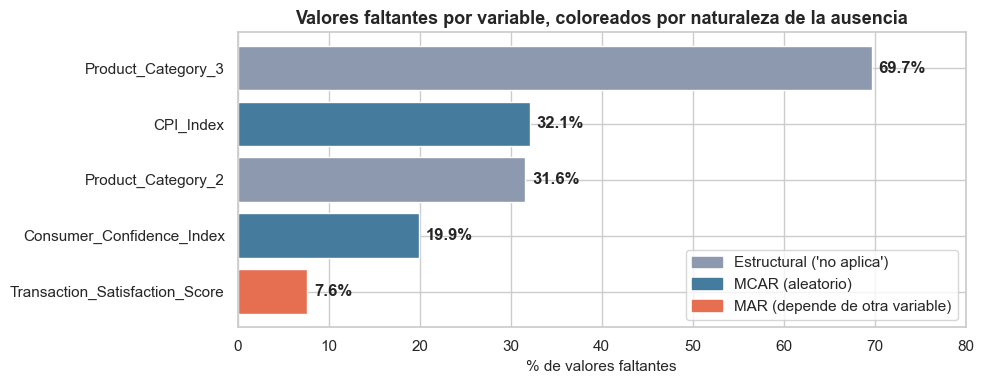

In [14]:
# --- Visual: magnitud y naturaleza de la ausencia -------------------------
tipo_na = {
    "Product_Category_3": "Estructural", "Product_Category_2": "Estructural",
    "CPI_Index": "MCAR", "Consumer_Confidence_Index": "MCAR",
    "Transaction_Satisfaction_Score": "MAR",
}
orden = tab_nulos.sort_values("% del total", ascending=True).index

fig, ax = plt.subplots(figsize=(10, 4))
colores = [PAL_NULL[tipo_na[c]] for c in orden]
barras = ax.barh(orden, tab_nulos.loc[orden, "% del total"], color=colores)
for b, v in zip(barras, tab_nulos.loc[orden, "% del total"]):
    ax.annotate(f"{v:.1f}%", (v, b.get_y() + b.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", va="center", fontweight="bold")
ax.set_xlim(0, 80)
ax.set_xlabel("% de valores faltantes")
ax.set_title("Valores faltantes por variable, coloreados por naturaleza de la ausencia")
manijas = [plt.Rectangle((0, 0), 1, 1, color=PAL_NULL[k]) for k in ["Estructural", "MCAR", "MAR"]]
ax.legend(manijas, ["Estructural ('no aplica')", "MCAR (aleatorio)", "MAR (depende de otra variable)"],
          loc="lower right")
plt.tight_layout(); plt.show()

**Conclusión (1.b).** Hay cinco variables con nulos, y **no todas faltan por el mismo motivo**:

| Variable | % nulos | Por qué falta | ¿Se puede recuperar? |
|---|---|---|---|
| `Product_Category_3` | ~70% | **Estructural**: el producto no tiene una tercera categoría | No, es un "no aplica" |
| `Product_Category_2` | ~32% | **Estructural**: el producto no tiene una segunda categoría | No, es un "no aplica" |
| `CPI_Index` | ~32% | **MCAR**: falta de forma pareja por año, canal y mes | **Sí**: es constante dentro del mes, se toma de otra fila |
| `Consumer_Confidence_Index` | ~20% | **MCAR**: mismo patrón que el CPI | **Sí**: igual que el CPI |
| `Transaction_Satisfaction_Score` | ~8% | **MAR**: falta más en `Online` que en `Store` y más de madrugada | No de forma exacta; necesita imputación |

- Los faltantes de las **categorías de producto** son los mismos que analizamos en el TP1: marcan
  productos con menos atributos, se asocian a un nivel de gasto distinto y conviene tratarlos como una
  **categoría explícita**, no imputarlos.
- Los indicadores **macro** (`CPI_Index`, `Consumer_Confidence_Index`) faltan al azar, pero como toman
  **un solo valor por mes**, cada nulo se puede **reconstruir exactamente** desde cualquier otra
  transacción del mismo mes. Ningún mes se queda sin ningún dato.
- `Transaction_Satisfaction_Score` es el único caso que pide una **imputación real**: su ausencia
  depende del canal y de la hora, no se puede reconstruir y es una variable numérica continua. Es la
  candidata natural para la imputación multivariada de la sección 3.b.

## 1.c Valores erróneos y consistencia temporal

Un dataset puede no tener nulos y aun así tener valores que no cierran: una hora que dice 26, una fecha
que cae fuera de su campaña, un `Is_Weekend` que marca fin de semana un martes. Para detectar ese tipo
de problema escribimos un conjunto de **reglas de consistencia**. Cada regla es una afirmación que
*debería* cumplirse siempre, y contamos cuántas filas la incumplen. Si el número es cero, esa parte del
archivo está sana.

Las reglas que aplicamos cubren cinco frentes:

1. **Coherencia de fecha y evento.** La fecha de compra tiene que caer dentro de su `Campaign_Year`; la
   hora tiene que estar entre 0 y 23; `Is_Weekend` tiene que coincidir con el día de la semana real; y
   `Days_To_Black_Friday` tiene que ser exactamente la distancia en días entre la fecha y el Black
   Friday de esa campaña (que calculamos como el día siguiente al cuarto jueves de noviembre).
2. **Coherencia de los indicadores mensuales.** El CPI, la inflación, la confianza y la actividad
   minorista son valores mensuales, así que dentro de un mismo mes no puede haber dos valores
   distintos. Lo mismo para el índice de actividad del rubro, que es un valor por mes y por categoría.
3. **Coherencia entre el CPI y la inflación.** El CPI es un índice de nivel de precios y
   `Monthly_Inflation_Rate` es su variación mensual. Entonces, la variación porcentual del CPI de un
   mes al siguiente tiene que ser igual a la inflación informada para ese mes. Si las dos cosas
   coinciden, quiere decir que el generador construyó el CPI acumulando mes a mes la inflación, y no de
   forma independiente.
4. **Dominios de las categóricas.** Género, edad, ciudad, antigüedad, estado civil, canal, ocupación y
   las categorías de producto tienen que tomar solo los valores permitidos.
5. **Rangos de las numéricas.** Los importes tienen que ser positivos y el puntaje de satisfacción
   tiene que estar en su escala de 1 a 10.

In [15]:
def black_friday(anio):
    # Black Friday = dia siguiente al 4o jueves de noviembre
    nov = pd.date_range(f"{anio}-11-01", f"{anio}-11-30", freq="D")
    cuarto_jueves = nov[nov.dayofweek == 3][3]
    return cuarto_jueves + pd.Timedelta(days=1)

BF = {a: black_friday(a) for a in sorted(df["Campaign_Year"].unique())}
print("Fechas de Black Friday detectadas:", {a: d.date().isoformat() for a, d in BF.items()})

reglas = {}

# 1) Purchase_Date pertenece a Campaign_Year
reglas["fecha fuera de su Campaign_Year"] = (df["Purchase_Date"].dt.year != df["Campaign_Year"]).sum()

# 2) Transaction_Hour en [0, 23]
reglas["Transaction_Hour fuera de 0-23"] = (~df["Transaction_Hour"].between(0, 23)).sum()

# 3) Is_Weekend coincide con el día de la semana real
weekend_real = (df["Purchase_Date"].dt.dayofweek >= 5).astype(int)
reglas["Is_Weekend no coincide con la fecha"] = (df["Is_Weekend"] != weekend_real).sum()

# 4) Days_To_Black_Friday coincide con (fecha - Black Friday de esa campaña)
d2bf_calc = (df["Purchase_Date"] - df["Campaign_Year"].map(BF)).dt.days
reglas["Days_To_Black_Friday inconsistente"] = (d2bf_calc != df["Days_To_Black_Friday"]).sum()

# 5) Indicadores macro: un único valor por mes
for col in ["CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
            "Retail_Activity_Index", "Retail_Activity_MoM"]:
    n_incons = (df.groupby("Purchase_Month")[col].nunique(dropna=True) > 1).sum()
    reglas[f"{col}: >1 valor en un mismo mes"] = n_incons

# 6) Indicador de rubro: un único valor por (mes, categoría)
reglas["Category_Activity_Index: >1 valor por (mes, categoría)"] = (
    df.groupby(["Purchase_Month", "Product_Category_1"])["Category_Activity_Index"].nunique() > 1
).sum()

# 7) Coherencia CPI <-> inflación mensual (la variación % del CPI debe seguir a la inflación)
macro_m = df.groupby("Purchase_Month").agg(cpi=("CPI_Index", "first"), infl=("Monthly_Inflation_Rate", "first"))
macro_m["cpi_var_pct"] = macro_m["cpi"].pct_change() * 100
desalineados = (macro_m["cpi_var_pct"] - macro_m["infl"]).abs() > 0.05  # tolerancia de redondeo
reglas["CPI vs inflación mensual desalineados"] = int(desalineados.sum())

# 8) Dominios de las categóricas
dominios = {
    "Gender": {"M", "F"},
    "Age": set(AGE_ORDER),
    "City_Category": {"A", "B", "C"},
    "Stay_In_Current_City_Years": {"0", "1", "2", "3", "4+"},
    "Marital_Status": {0, 1},
    "Sales_Channel": {"Online", "Store"},
    "Occupation": set(range(21)),
}
for col, dom in dominios.items():
    reglas[f"{col} fuera de dominio"] = (~df[col].isin(dom)).sum()

# Categorías de producto dentro de un rango razonable (1-20)
for col in ["Product_Category_1", "Product_Category_2", "Product_Category_3"]:
    reglas[f"{col} fuera de 1-20"] = (~df[col].dropna().between(1, 20)).sum()

# 9) Importes positivos
reglas["Purchase <= 0"] = (df["Purchase"] <= 0).sum()

# 10) Satisfacción en su escala [1, 10]
reglas["Transaction_Satisfaction_Score fuera de 1-10"] = (
    ~df["Transaction_Satisfaction_Score"].dropna().between(1, 10)
).sum()

resultado = pd.DataFrame({"filas que violan la regla": pd.Series(reglas)})
resultado["estado"] = np.where(resultado["filas que violan la regla"] == 0, "PASA", "REVISAR")
resultado

Fechas de Black Friday detectadas: {2022: '2022-11-25', 2023: '2023-11-24', 2024: '2024-11-29'}


,filas que violan la regla,estado
fecha fuera de su Campaign_Year,0,PASA
Transaction_Hour fuera de 0-23,0,PASA
Is_Weekend no coincide con la fecha,0,PASA
Days_To_Black_Friday inconsistente,0,PASA
CPI_Index: >1 valor en un mismo mes,0,PASA
Monthly_Inflation_Rate: >1 valor en un mismo mes,0,PASA
Consumer_Confidence_Index: >1 valor en un mismo mes,0,PASA
Retail_Activity_Index: >1 valor en un mismo mes,0,PASA
Retail_Activity_MoM: >1 valor en un mismo mes,0,PASA
"Category_Activity_Index: >1 valor por (mes, categoría)",0,PASA


El gráfico siguiente es la comprobación visual del punto 3: ponemos el CPI mes a mes junto con la
inflación mensual y verificamos que el índice suba exactamente al ritmo que marca la inflación.

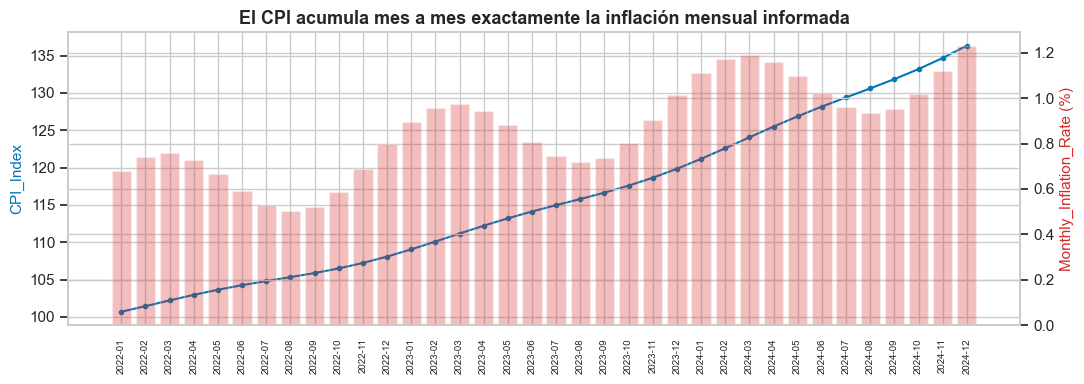

Correlación entre variación % del CPI e inflación mensual informada: 1.00000


In [16]:
# Verificación visual de la coherencia CPI <-> inflación acumulada
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(macro_m.index.astype(str), macro_m["cpi"], color=C_TREND, marker="o", ms=3, label="CPI_Index")
ax1.set_ylabel("CPI_Index", color=C_TREND); ax1.tick_params(axis="x", rotation=90, labelsize=7)
ax2 = ax1.twinx()
ax2.bar(macro_m.index.astype(str), macro_m["infl"], alpha=0.3, color=C_MA28, label="Inflación mensual (%)")
ax2.set_ylabel("Monthly_Inflation_Rate (%)", color=C_MA28)
ax1.set_title("El CPI acumula mes a mes exactamente la inflación mensual informada")
plt.tight_layout(); plt.show()

print(f"Correlación entre variación % del CPI e inflación mensual informada: "
      f"{macro_m[['cpi_var_pct', 'infl']].dropna().corr().iloc[0, 1]:.5f}")

**Conclusión (1.c).** **Todas las reglas dan cero.** No encontramos una sola fila con fecha fuera de su
campaña, hora inválida, `Is_Weekend` mal calculado, `Days_To_Black_Friday` incoherente, categoría fuera
de dominio, importe no positivo o indicador económico contradictorio dentro de un mismo mes. El
`CPI_Index` acumula mes a mes **exactamente** la `Monthly_Inflation_Rate` (la correlación entre la
variación del CPI y la inflación informada da 1,000), y `Retail_Activity_MoM` reproduce la variación
intermensual de `Retail_Activity_Index`.

Esto es lo esperable en un dataset **sintético bien construido**: los únicos problemas reales de calidad
son los **valores faltantes** (1.b) y los **outliers** de `Purchase` (1.d). No hay errores de
codificación para corregir. Lo dejamos anotado para la sección 3.a y para la re-verificación de la
sección 5.

## 1.d Outliers de `Purchase`

`Purchase` es la variable central del trabajo, así que miramos su cola superior con cuidado. La
pregunta no es solo "¿cuántos valores altos hay?", sino sobre todo "¿de dónde vienen?". Nos interesa
distinguir tres cosas que se ven parecidas en un boxplot pero significan cosas muy distintas:

- **errores de carga** (un monto imposible, un tipeo), que habría que corregir o descartar;
- **transacciones de alto valor legítimas** (alguien compró algo caro), que son datos reales y hay que
  conservar;
- **picos comerciales legítimos** (muchas compras concentradas en Black Friday), que son la señal más
  importante del dataset y no se tocan.

Para eso miramos la distribución global, el corte por campaña y por categoría de producto, y en qué
parte del calendario caen las compras más caras. Todavía no modificamos nada.

In [17]:
p = df["Purchase"]
q1, q3 = p.quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
n_out = (p > lim_sup).sum()

print(f"Purchase, min {p.min():,.0f} | mediana {p.median():,.0f} | media {p.mean():,.0f} | max {p.max():,.0f}")
print(f"Asimetría (skew): {p.skew():.3f}")
print(f"Límite superior IQR (Q3 + 1.5*IQR): {lim_sup:,.0f}")
print(f"Transacciones por encima del límite: {n_out:,}  ({n_out / len(df) * 100:.2f}%)")
print()
print("Percentiles altos:")
print(p.quantile([0.90, 0.95, 0.99, 0.999, 1.0]).round(0))

Purchase, min 11 | mediana 9,392 | media 10,694 | max 38,968
Asimetría (skew): 0.710
Límite superior IQR (Q3 + 1.5*IQR): 25,964
Transacciones por encima del límite: 19,594  (1.19%)

Percentiles altos:
0.900   19,653.000
0.950   22,128.000
0.990   26,319.000
0.999   30,287.000
1.000   38,968.000
Name: Purchase, dtype: float64


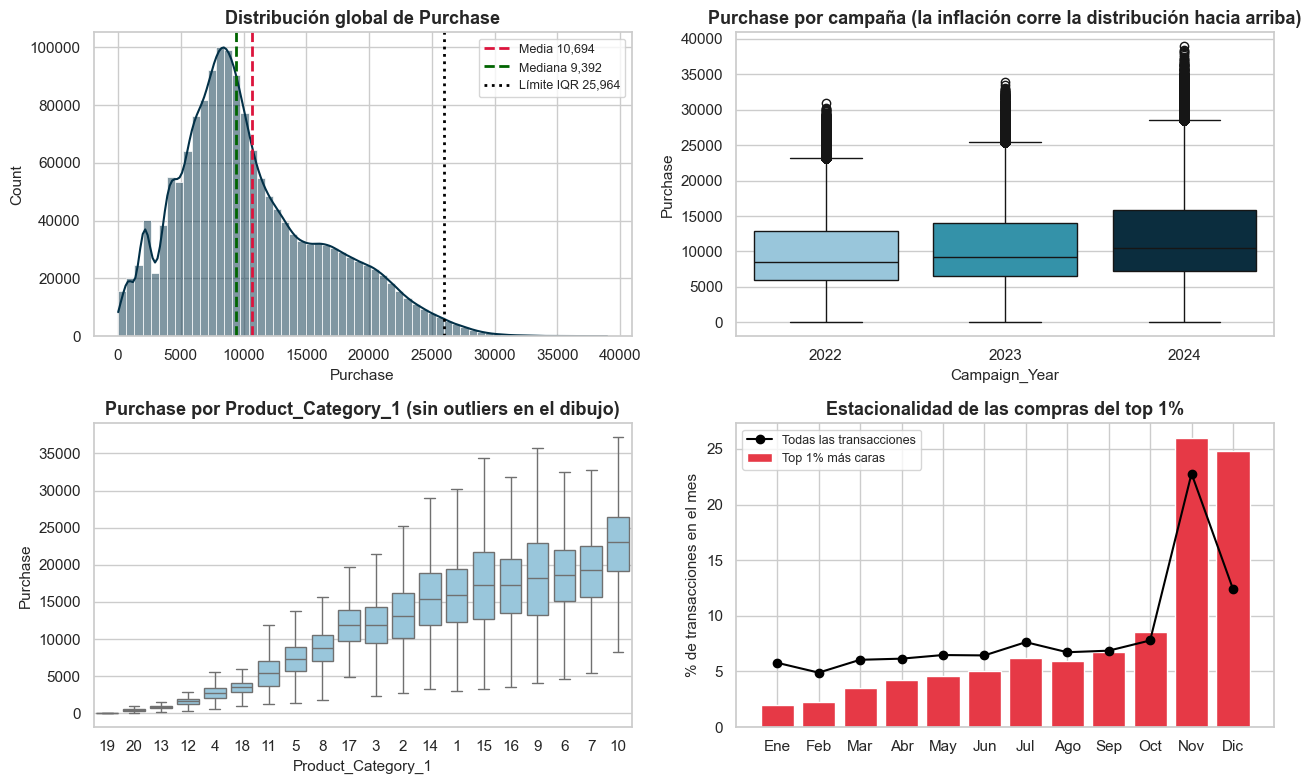

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) Distribución global
sns.histplot(p, bins=60, kde=True, color=C_SALES, ax=axes[0, 0])
axes[0, 0].axvline(p.mean(), color="crimson", ls="--", lw=2, label=f"Media {p.mean():,.0f}")
axes[0, 0].axvline(p.median(), color="darkgreen", ls="--", lw=2, label=f"Mediana {p.median():,.0f}")
axes[0, 0].axvline(lim_sup, color="black", ls=":", lw=2, label=f"Límite IQR {lim_sup:,.0f}")
axes[0, 0].legend(fontsize=9); axes[0, 0].set_title("Distribución global de Purchase")

# (b) Por campaña
sns.boxplot(data=df, x="Campaign_Year", y="Purchase", hue="Campaign_Year",
            palette=PAL_CAMPAIGN, legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Purchase por campaña (la inflación corre la distribución hacia arriba)")

# (c) Por categoría principal de producto
orden_cat = df.groupby("Product_Category_1")["Purchase"].median().sort_values().index
sns.boxplot(data=df, x="Product_Category_1", y="Purchase", order=orden_cat,
            color="#8ecae6", showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Purchase por Product_Category_1 (sin outliers en el dibujo)")

# (d) ¿Dónde caen las transacciones más caras en el calendario?
top1pct = df[df["Purchase"] > p.quantile(0.99)]
share_mes = top1pct["Month_name"].value_counts().reindex(MES_ORDER).fillna(0)
share_all = df["Month_name"].value_counts().reindex(MES_ORDER).fillna(0)
axes[1, 1].bar(MES_ORDER, (share_mes / top1pct.shape[0] * 100), color="#e63946", label="Top 1% más caras")
axes[1, 1].plot(MES_ORDER, (share_all / len(df) * 100), color="black", marker="o", label="Todas las transacciones")
axes[1, 1].set_ylabel("% de transacciones en el mes"); axes[1, 1].legend(fontsize=9)
axes[1, 1].set_title("Estacionalidad de las compras del top 1%")

plt.tight_layout(); plt.show()

In [19]:
# Outliers por campaña: ¿es un problema de datos o es el efecto precio?
resumen_out = (df.assign(es_outlier=df["Purchase"] > lim_sup)
                 .groupby("Campaign_Year")
                 .agg(pct_outliers=("es_outlier", "mean"),
                      purchase_medio=("Purchase", "mean"),
                      purchase_max=("Purchase", "max")))
resumen_out["pct_outliers"] = (resumen_out["pct_outliers"] * 100).round(2)
display(resumen_out)

print("Top 5 días por venta total (¿coinciden con el evento?):")
top_dias = (df.groupby("Purchase_Date")["Purchase"].sum().sort_values(ascending=False).head(5))
for d, v in top_dias.items():
    dias_a_bf = df.loc[df["Purchase_Date"] == d, "Days_To_Black_Friday"].iloc[0]
    print(f"  {d.date()}  ({d.day_name()[:3]})  ->  ${v:,.0f}   | Days_To_BF = {dias_a_bf}")

,pct_outliers,purchase_medio,purchase_max
Campaign_Year,,,
2022,0.110,"9,644.295",30912
2023,0.500,"10,558.095",33857
2024,2.960,"11,879.436",38968


Top 5 días por venta total (¿coinciden con el evento?):
  2024-12-02  (Mon)  ->  $216,682,723   | Days_To_BF = 3
  2024-11-30  (Sat)  ->  $177,296,918   | Days_To_BF = 1
  2023-11-27  (Mon)  ->  $174,605,709   | Days_To_BF = 3
  2024-12-01  (Sun)  ->  $165,475,835   | Days_To_BF = 2
  2022-11-28  (Mon)  ->  $157,554,243   | Days_To_BF = 3


**Conclusión (1.d).** `Purchase` tiene una distribución con varios picos (uno por rango de precio de
categoría, igual que en el TP1) y una **asimetría positiva leve** (el `skew` da alrededor de 0,7). El
criterio del rango intercuartílico marca cerca del **1,2% de las transacciones** como outliers, pero al
mirarlas de cerca vemos los tres casos que buscábamos:

1. **Errores de carga:** no hay. El mínimo y el máximo son montos plausibles para compras reales, sin
   valores negativos, nulos ni absurdos.
2. **Transacciones de alto valor legítimas:** son la cola superior de la distribución y se explican por
   las categorías de producto más caras que ya identificamos en el TP1. Son reales.
3. **Picos comerciales legítimos:** las compras del 1% más caro se concentran en noviembre y diciembre,
   y los cinco días de mayor facturación caen todos en la ventana de Black Friday y Cyber Monday. No es
   ruido, es **el evento**.

Además, la media de `Purchase` sube de una campaña a la siguiente siguiendo la inflación acumulada del
`CPI_Index` (se ve en la columna `purchase_medio` de la tabla). Eso **no es un problema de datos**, es
el efecto precio: los mismos productos valen más cada año. También explica por qué el porcentaje de
"outliers" según un umbral fijo crece campaña a campaña.

**Qué proponemos hacer (recién en la sección 3, no ahora):** no eliminar ninguna transacción por ser
outlier. Para los análisis y modelos sensibles a la escala, evaluar una winsorización al percentil 99,5
o trabajar con `log1p(Purchase)`, y **guardar un flag** `Purchase_es_outlier` para poder analizar esas
compras por separado. Los picos del evento se conservan siempre.

---
# 2. Análisis exploratorio temporal

Para todo el análisis de series de tiempo construimos primero una **tabla diaria**: una fila por día,
con la venta total, la cantidad de transacciones, el ticket promedio y los clientes activos de ese día.
Es una tabla **auxiliar** y no se guarda como entregable (eso lo aclara la consigna en el punto 6).

In [20]:
serie = (df.groupby("Purchase_Date")
           .agg(Daily_Sales=("Purchase", "sum"),
                Transactions=("Purchase", "size"),
                Avg_Ticket=("Purchase", "mean"),
                Clientes_activos=("User_ID", "nunique"))
           .sort_index())
serie["Campaign_Year"] = serie.index.year
serie["DOW"] = serie.index.dayofweek
serie["DOW_name"] = serie["DOW"].map(dict(enumerate(DOW_ORDER)))
serie["Month"] = serie.index.month
serie["Month_name"] = serie["Month"].map(dict(enumerate(MES_ORDER, start=1)))
serie["Days_To_BF"] = (serie.index - pd.Series(serie.index.year, index=serie.index).map(BF)).dt.days

print(f"Tabla diaria: {serie.shape[0]} filas (días) x {serie.shape[1]} columnas")
serie.head()

Tabla diaria: 1096 filas (días) x 10 columnas


,Daily_Sales,Transactions,Avg_Ticket,Clientes_activos,Campaign_Year,DOW,DOW_name,Month,Month_name,Days_To_BF
Purchase_Date,,,,,,,,,,
2022-01-01,10668768,1184,"9,010.784",960,2022,5,Sáb,1,Ene,-328
2022-01-02,11276225,1222,"9,227.680",988,2022,6,Dom,1,Ene,-327
2022-01-03,8485441,919,"9,233.342",761,2022,0,Lun,1,Ene,-326
2022-01-04,8808836,974,"9,043.979",819,2022,1,Mar,1,Ene,-325
2022-01-05,8900576,938,"9,488.887",795,2022,2,Mié,1,Ene,-324


## 2.a Evolución y estacionalidad

Acá miramos cómo se mueven las ventas en el tiempo: la serie diaria completa, el corte por día de la
semana y por mes, la comparación entre campañas con un índice que las haga comparables, y el
comportamiento alrededor de Black Friday con los tres años superpuestos.

Una aclaración que atraviesa toda la sección: **`sum` y `mean` responden preguntas distintas**. La
suma de `Purchase` mide **cuánto se facturó** (volumen); el promedio mide **cuánto salió cada compra**
(ticket). En Black Friday puede pasar que se dispare la primera sin que se mueva la segunda.

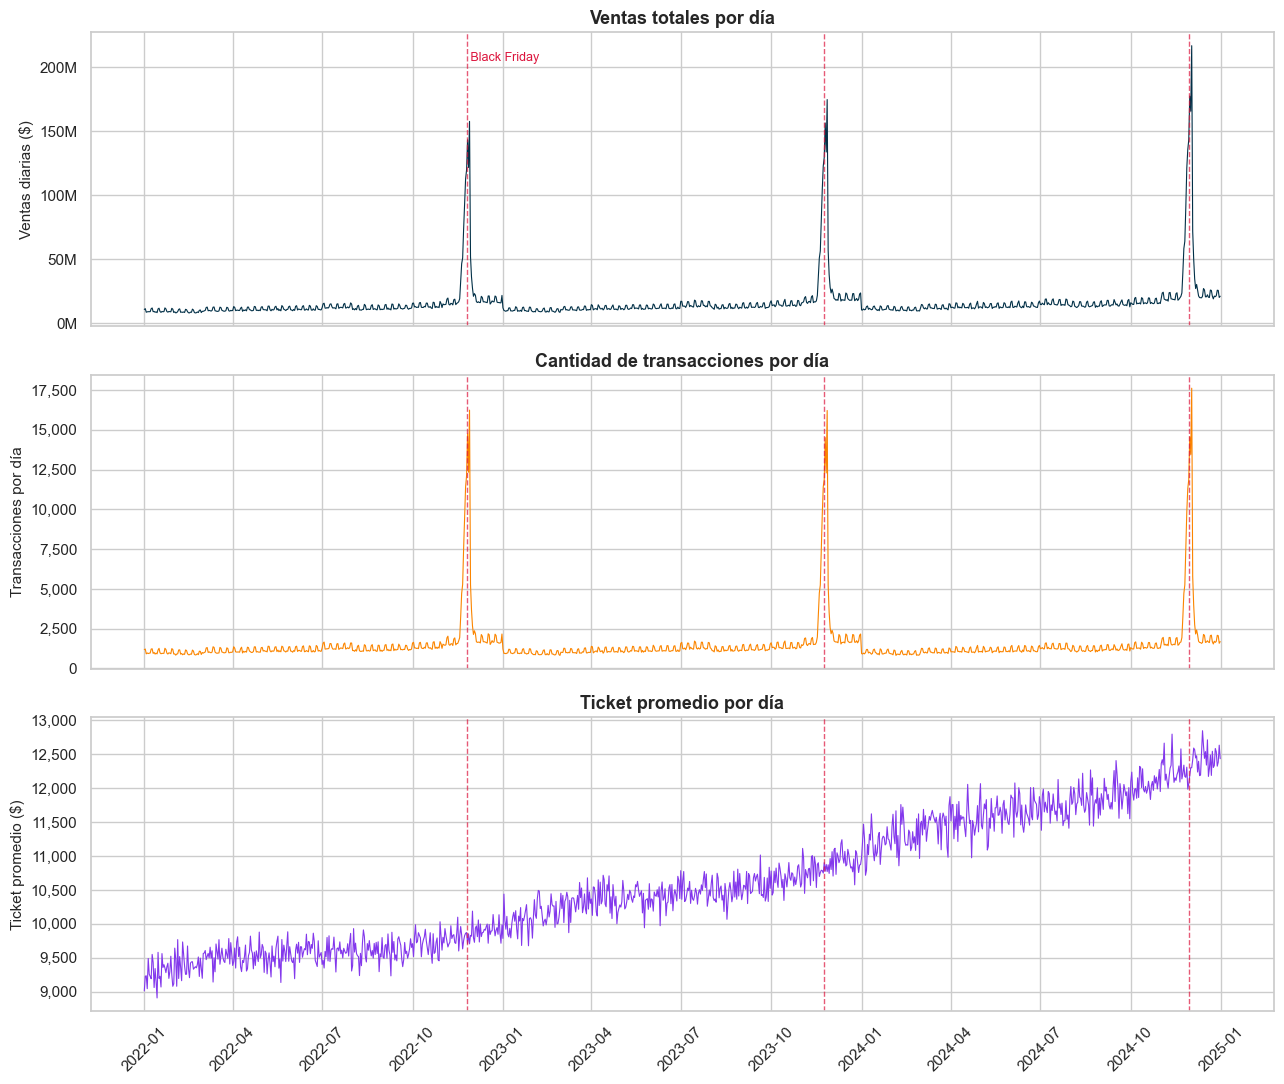

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(serie.index, serie["Daily_Sales"], color=C_SALES, lw=0.8)
axes[0].set_ylabel("Ventas diarias ($)"); millones(axes[0])
axes[0].set_title("Ventas totales por día")

axes[1].plot(serie.index, serie["Transactions"], color=C_TX, lw=0.8)
axes[1].set_ylabel("Transacciones por día"); miles(axes[1])
axes[1].set_title("Cantidad de transacciones por día")

axes[2].plot(serie.index, serie["Avg_Ticket"], color=C_TICKET, lw=0.8)
axes[2].set_ylabel("Ticket promedio ($)"); miles(axes[2])
axes[2].set_title("Ticket promedio por día")

for ax in axes:
    for a, d in BF.items():
        ax.axvline(d, color="crimson", ls="--", lw=1, alpha=0.7)
axes[0].text(BF[2022], axes[0].get_ylim()[1] * 0.9, " Black Friday", color="crimson", fontsize=9)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

El ticket promedio diario de arriba está en **pesos corrientes**, así que parte de lo que se ve es solo
inflación. Para saber si el valor de una compra típica realmente cambió, lo comparamos con su versión
**deflactada**: dividimos el ticket de cada mes por el CPI de ese mes y lo llevamos a los precios del
primer mes de la serie. Si la curva deflactada queda plana, quiere decir que el ticket "real" no se
movió y todo el crecimiento nominal era precio.

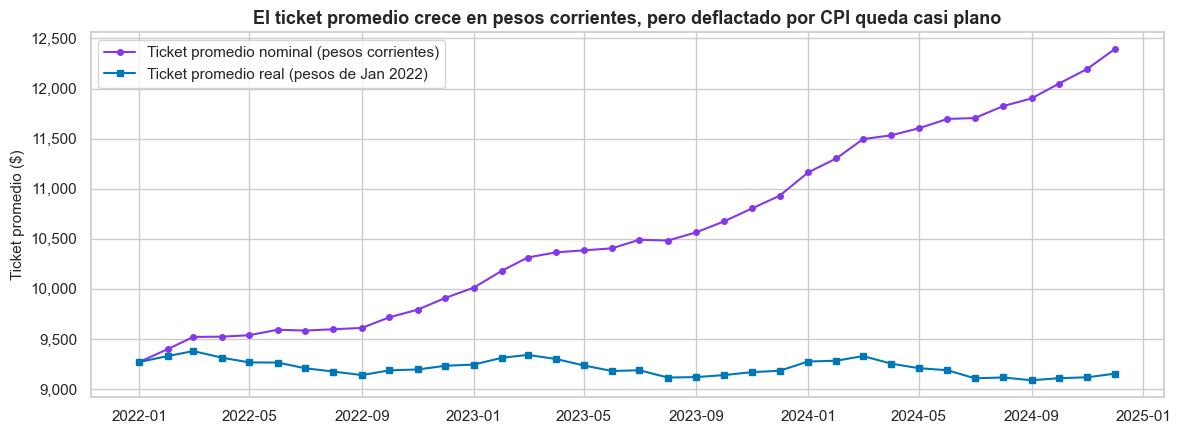

Variación del ticket promedio entre el primer y el último mes:
  nominal (pesos corrientes) : +33.7%
  real (deflactado por CPI)  : -1.3%


In [22]:
# Ticket promedio mensual: nominal contra real (deflactado por CPI)
tick_mes = (df.groupby("Purchase_Month")
              .agg(Ticket_nominal=("Purchase", "mean"),
                   CPI=("CPI_Index", "median")))   # el CPI es constante dentro del mes
tick_mes.index = tick_mes.index.to_timestamp()
cpi_base = tick_mes["CPI"].iloc[0]
tick_mes["Ticket_real"] = tick_mes["Ticket_nominal"] / tick_mes["CPI"] * cpi_base

var_nominal = tick_mes["Ticket_nominal"].iloc[-1] / tick_mes["Ticket_nominal"].iloc[0] - 1
var_real    = tick_mes["Ticket_real"].iloc[-1]    / tick_mes["Ticket_real"].iloc[0]    - 1

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(tick_mes.index, tick_mes["Ticket_nominal"], marker="o", ms=4, color=C_TICKET,
        label="Ticket promedio nominal (pesos corrientes)")
ax.plot(tick_mes.index, tick_mes["Ticket_real"], marker="s", ms=4, color=C_TREND,
        label=f"Ticket promedio real (pesos de {tick_mes.index[0]:%b %Y})")
ax.set_ylabel("Ticket promedio ($)"); miles(ax)
ax.set_title("El ticket promedio crece en pesos corrientes, pero deflactado por CPI queda casi plano")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

print(f"Variación del ticket promedio entre el primer y el último mes:")
print(f"  nominal (pesos corrientes) : {var_nominal:+.1%}")
print(f"  real (deflactado por CPI)  : {var_real:+.1%}")

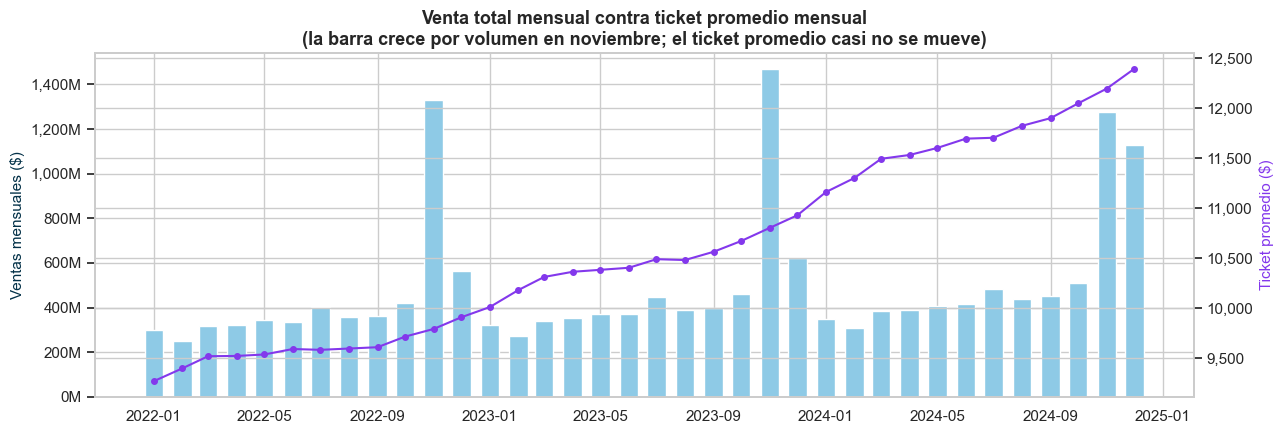

In [23]:
# Ticket promedio y venta total por MES (dos preguntas distintas)
mensual = (df.groupby("Purchase_Month")
             .agg(Ventas=("Purchase", "sum"), Tx=("Purchase", "size"), Ticket=("Purchase", "mean")))
mensual.index = mensual.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.bar(mensual.index, mensual["Ventas"], width=20, color="#8ecae6", label="Ventas del mes")
ax1.set_ylabel("Ventas mensuales ($)", color=C_SALES); millones(ax1)
ax2 = ax1.twinx()
ax2.plot(mensual.index, mensual["Ticket"], color=C_TICKET, marker="o", ms=4, label="Ticket promedio")
ax2.set_ylabel("Ticket promedio ($)", color=C_TICKET); miles(ax2)
ax1.set_title("Venta total mensual contra ticket promedio mensual\n"
              "(la barra crece por volumen en noviembre; el ticket promedio casi no se mueve)")
plt.tight_layout(); plt.show()

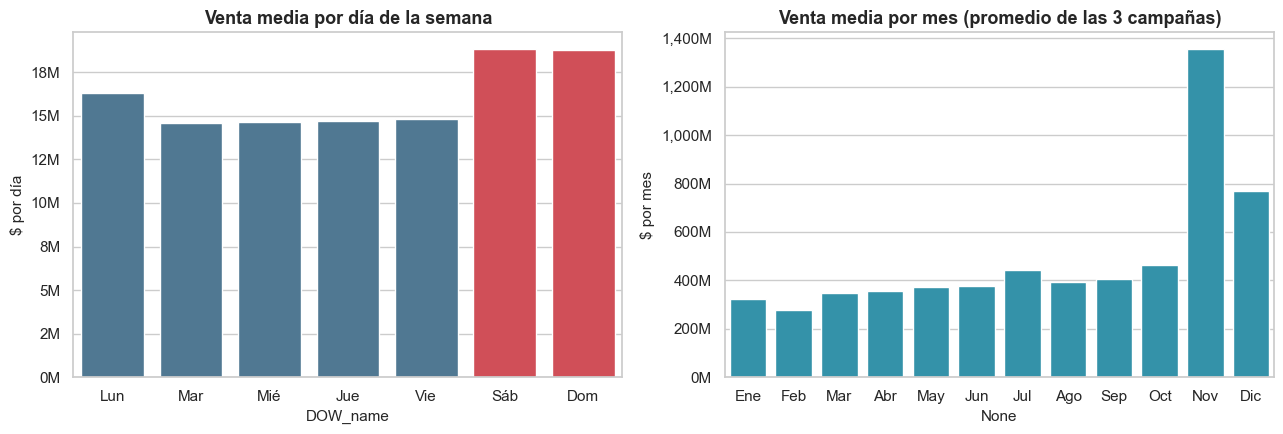

Venta media de un día de fin de semana contra uno hábil: +25%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Ventas por día de la semana
v_dow = serie.groupby("DOW_name")["Daily_Sales"].mean().reindex(DOW_ORDER)
sns.barplot(x=v_dow.index, y=v_dow.values, hue=v_dow.index, palette=PAL_DOW, legend=False, ax=axes[0])
axes[0].set_title("Venta media por día de la semana"); axes[0].set_ylabel("$ por día"); millones(axes[0])

# Ventas por mes (promedio de las tres campañas)
v_mes = mensual.groupby(mensual.index.month)["Ventas"].mean()
v_mes.index = [MES_ORDER[m - 1] for m in v_mes.index]
sns.barplot(x=v_mes.index, y=v_mes.values, color="#219ebc", ax=axes[1])
axes[1].set_title("Venta media por mes (promedio de las 3 campañas)"); axes[1].set_ylabel("$ por mes")
millones(axes[1])
plt.tight_layout(); plt.show()

finde = serie.loc[serie["DOW"] >= 5, "Daily_Sales"].mean()
habil = serie.loc[serie["DOW"] < 5, "Daily_Sales"].mean()
print(f"Venta media de un día de fin de semana contra uno hábil: {finde / habil - 1:+.0%}")

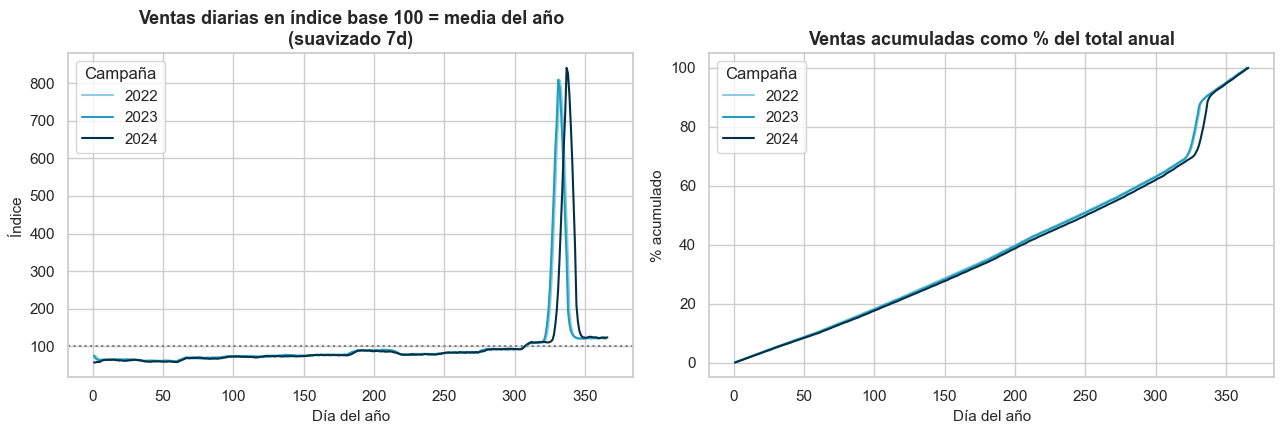

In [25]:
# Evolución por campaña con índices comparables:
# cada año se lleva a base 100 = venta media diaria de ESE año, y se acumula el % del total anual.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for a in sorted(serie["Campaign_Year"].unique()):
    s = serie[serie["Campaign_Year"] == a].copy()
    s["doy"] = s.index.dayofyear
    idx = s["Daily_Sales"] / s["Daily_Sales"].mean() * 100
    axes[0].plot(s["doy"], idx.rolling(7, min_periods=1).mean(), color=PAL_CAMPAIGN[a], label=str(a))
    acum = s["Daily_Sales"].cumsum() / s["Daily_Sales"].sum() * 100
    axes[1].plot(s["doy"], acum, color=PAL_CAMPAIGN[a], label=str(a))

axes[0].axhline(100, color="grey", ls=":")
axes[0].set_title("Ventas diarias en índice base 100 = media del año\n(suavizado 7d)")
axes[0].set_xlabel("Día del año"); axes[0].set_ylabel("Índice"); axes[0].legend(title="Campaña")
axes[1].set_title("Ventas acumuladas como % del total anual")
axes[1].set_xlabel("Día del año"); axes[1].set_ylabel("% acumulado"); axes[1].legend(title="Campaña")
plt.tight_layout(); plt.show()

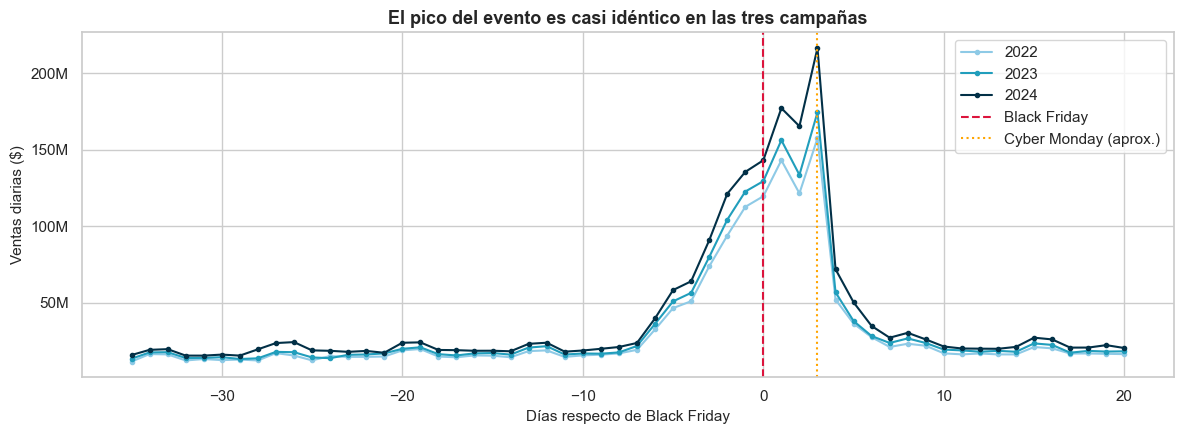

Facturación de las últimas 6 semanas sobre el total anual: 31%


In [26]:
# Ventas según Days_To_Black_Friday, los tres años superpuestos (ventana -35 a +20)
ventana = serie[serie["Days_To_BF"].between(-35, 20)]
fig, ax = plt.subplots(figsize=(12, 4.5))
for a in sorted(ventana["Campaign_Year"].unique()):
    s = ventana[ventana["Campaign_Year"] == a]
    ax.plot(s["Days_To_BF"], s["Daily_Sales"], color=PAL_CAMPAIGN[a], marker="o", ms=3, label=str(a))
ax.axvline(0, color="crimson", ls="--", label="Black Friday")
ax.axvline(3, color="orange", ls=":", label="Cyber Monday (aprox.)")
ax.set_xlabel("Días respecto de Black Friday"); ax.set_ylabel("Ventas diarias ($)"); millones(ax)
ax.set_title("El pico del evento es casi idéntico en las tres campañas")
ax.legend(); plt.tight_layout(); plt.show()

# ¿Qué parte de la facturación anual cae en las últimas 6 semanas del año?
ult6 = serie[serie.index.dayofyear >= 365 - 42]
print(f"Facturación de las últimas 6 semanas sobre el total anual: "
      f"{ult6['Daily_Sales'].sum() / serie['Daily_Sales'].sum():.0%}")

**Conclusión (2.a).**

- **Estacionalidad semanal marcada:** un día de fin de semana vende alrededor de un 25% más que uno
  hábil, tanto en monto como en transacciones. Es lo que se ve como el "grosor" de la serie diaria.
- **Estacionalidad anual dominada por el evento:** noviembre concentra la mayor venta del año y hay un
  segundo repunte en diciembre por Navidad. El resto del año es un piso bastante parejo.
- **El pico de Black Friday es estructural:** al alinear por `Days_To_Black_Friday`, las tres campañas
  se superponen casi perfectamente. La ventana que va de dos días antes a cuatro días después
  multiplica varias veces la venta diaria normal. El generador reproduce el mismo shock todos los años.
- **`sum` contra `mean`:** la venta mensual se dispara en noviembre por **volumen** (muchísimas más
  transacciones), mientras que el ticket promedio casi no cambia de un mes a otro. En Black Friday no
  se compra más caro, se compra **mucho más**.
- **El ticket "real" casi no se movió:** en pesos corrientes el ticket promedio crece a lo largo de la
  serie, pero al deflactarlo por el CPI queda prácticamente plano. Todo ese crecimiento era inflación,
  no un cambio de comportamiento.
- **Comparabilidad entre campañas:** al llevar cada año a un índice base 100, las tres curvas coinciden
  en forma, y la curva de venta acumulada muestra que cerca de un 30% de la facturación anual se
  hace en las últimas seis semanas del año.

## 2.b Tendencia y medias móviles

Una serie diaria de ventas mezcla tres cosas: una **tendencia** de fondo (hacia dónde va el nivel a lo
largo de los meses), una **estacionalidad** que se repite (el diente de sierra de la semana) y **picos
de evento** puntuales. Las medias móviles son la herramienta más simple para separarlas.

Una media móvil de `w` días reemplaza el valor de cada día por el promedio de los últimos `w` días. Al
promediar, los sube y baja de alta frecuencia se cancelan y queda a la vista lo que se mueve despacio:

- la **media móvil de 7 días** promedia una semana completa, así que elimina el efecto del día de la
  semana y deja ver la tendencia de corto plazo;
- la **media móvil de 28 días** promedia cuatro semanas y suaviza todavía más, mostrando la tendencia
  de fondo.

También comparamos la serie con una **descomposición** (que separa explícitamente tendencia,
estacionalidad semanal y residuo) y con **diferencias temporales** (restarle a cada día el de 1 o 7
días antes), que logran un efecto parecido de forma más directa.

Un detalle sobre los **bordes**: los primeros días de la serie no tienen suficiente historia atrás para
llenar la ventana. Ahí la media móvil queda indefinida. No la rellenamos, porque inventar valores hacia
atrás sesgaría el arranque de la serie; simplemente esos días quedan sin valor y se excluyen del
gráfico.

In [27]:
s = serie["Daily_Sales"].astype(float)
serie["MA7"] = s.rolling(7, min_periods=7).mean()
serie["MA28"] = s.rolling(28, min_periods=28).mean()

sin_hist = serie[["MA7", "MA28"]].isna().sum()
print("Días sin valor de media móvil (borde inicial, sin historia suficiente):")
print(f"  MA7  -> {sin_hist['MA7']} días  (los primeros 6)")
print(f"  MA28 -> {sin_hist['MA28']} días  (los primeros 27)")
print("Criterio: min_periods = tamaño de la ventana, así que el borde queda en NaN y no se rellena.")

Días sin valor de media móvil (borde inicial, sin historia suficiente):
  MA7  -> 6 días  (los primeros 6)
  MA28 -> 27 días  (los primeros 27)
Criterio: min_periods = tamaño de la ventana, así que el borde queda en NaN y no se rellena.


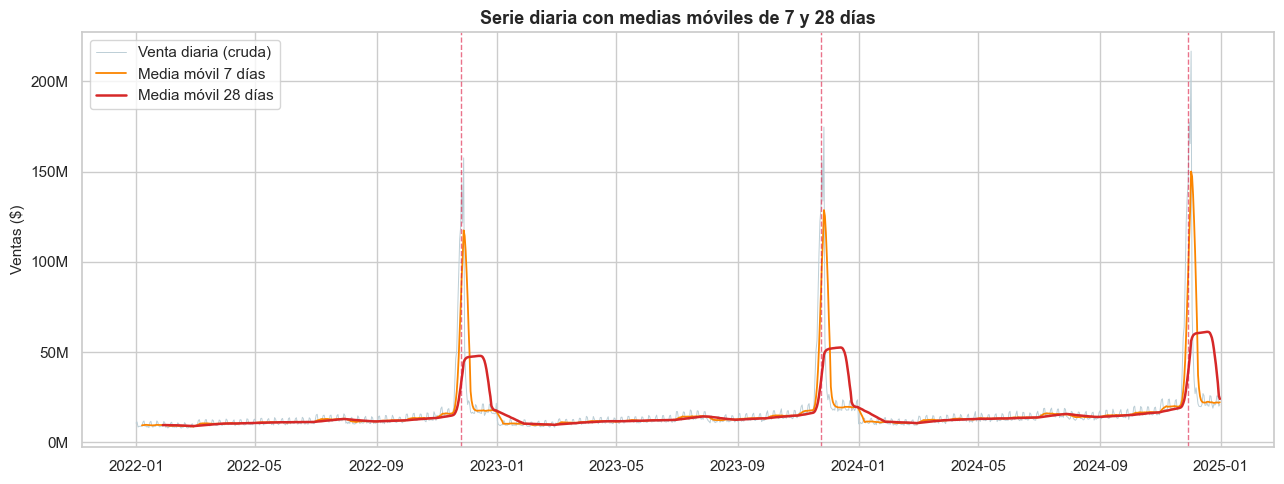

In [28]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie.index, s, color="#bcced6", lw=0.7, label="Venta diaria (cruda)")
ax.plot(serie.index, serie["MA7"], color=C_MA7, lw=1.3, label="Media móvil 7 días")
ax.plot(serie.index, serie["MA28"], color=C_MA28, lw=1.8, label="Media móvil 28 días")
for d in BF.values():
    ax.axvline(d, color="crimson", ls="--", lw=1, alpha=0.6)
ax.set_ylabel("Ventas ($)"); millones(ax)
ax.set_title("Serie diaria con medias móviles de 7 y 28 días")
ax.legend(); plt.tight_layout(); plt.show()

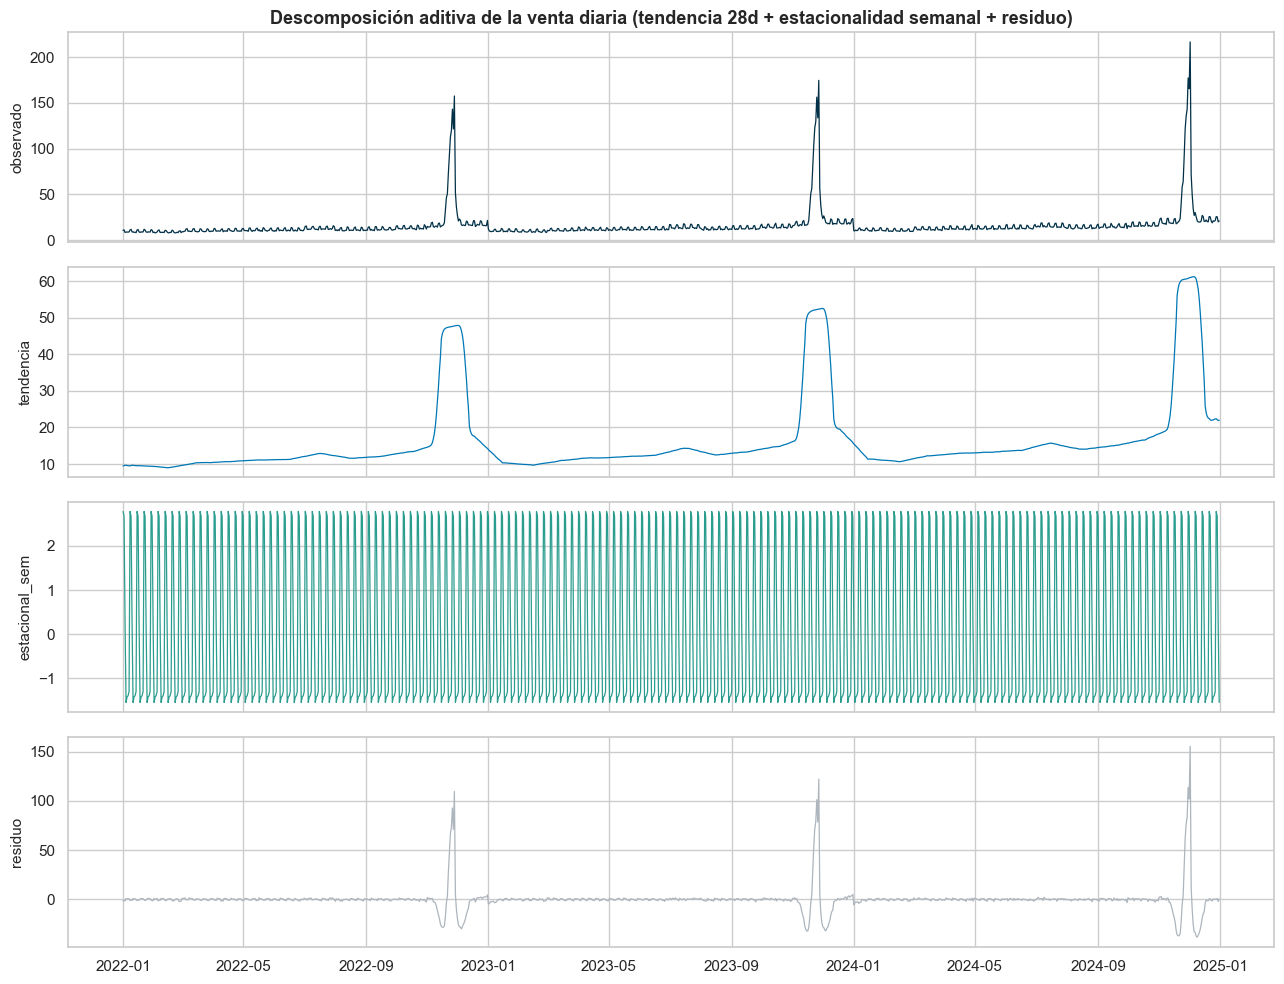

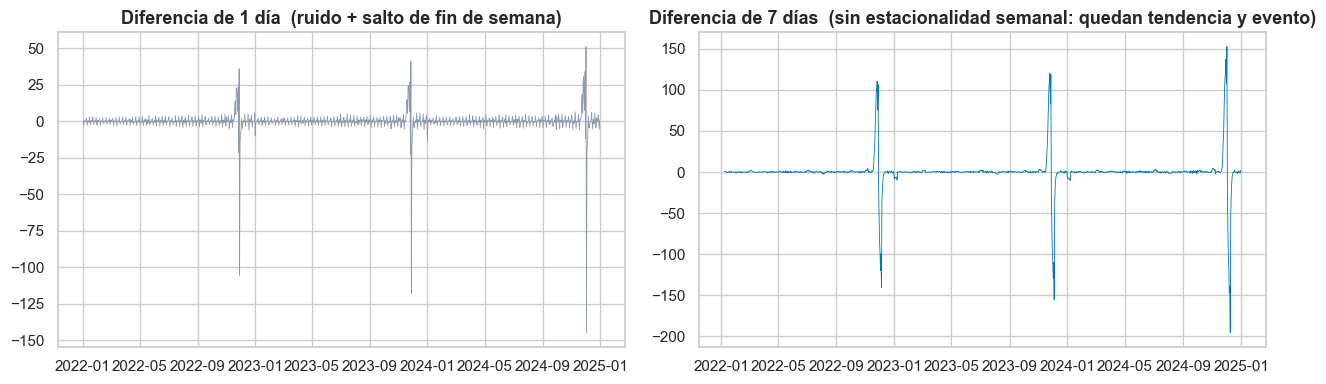

In [29]:
# Descomposición aditiva manual (sin statsmodels): tendencia = MA28 centrada,
# estacionalidad semanal = media del residuo por día de semana.
dec = pd.DataFrame({"observado": s})
dec["tendencia"] = s.rolling(28, center=True, min_periods=14).mean()
detr = s - dec["tendencia"]
dec["estacional_sem"] = detr.groupby(s.index.dayofweek).transform("mean")
dec["residuo"] = s - dec["tendencia"] - dec["estacional_sem"]

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, col, color in zip(axes, ["observado", "tendencia", "estacional_sem", "residuo"],
                          [C_SALES, C_TREND, "#2a9d8f", "#adb5bd"]):
    ax.plot(dec.index, dec[col] / 1e6, color=color, lw=0.9)
    ax.set_ylabel(col)
axes[0].set_title("Descomposición aditiva de la venta diaria (tendencia 28d + estacionalidad semanal + residuo)")
plt.tight_layout(); plt.show()

# Diferencias temporales: la d7 elimina la estacionalidad semanal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(serie.index, s.diff(1) / 1e6, color="#8d99ae", lw=0.6)
axes[0].set_title("Diferencia de 1 día  (ruido + salto de fin de semana)")
axes[1].plot(serie.index, s.diff(7) / 1e6, color="#0077b6", lw=0.6)
axes[1].set_title("Diferencia de 7 días  (sin estacionalidad semanal: quedan tendencia y evento)")
plt.tight_layout(); plt.show()

**Conclusión (2.b).**

- **Tendencia:** la media móvil de 28 días es suavemente **creciente** a lo largo de los tres años.
  Como la cantidad de transacciones por campaña es idéntica, esa tendencia es casi enteramente **efecto
  precio** (la inflación acumulada en el `CPI_Index`), más una leve reasignación de compras hacia fin
  de año.
- **Estacionalidad semanal:** la media móvil de 7 días borra el diente de sierra de lunes a domingo y
  deja ver que el componente semanal es **estable y de amplitud grande** (los fines de semana aportan
  sistemáticamente más).
- **Picos de evento:** ni la media de 7 ni la de 28 días "absorben" el pico de noviembre. Queda como un
  salto neto en la tendencia suavizada y como el gran residuo positivo de la descomposición. Es un
  shock, no estacionalidad común.
- **Descomposición contra diferencias:** la descomposición separa de forma explícita los tres
  componentes; la diferencia de 7 días consigue un efecto parecido de manera más simple (mata la
  estacionalidad semanal y deja tendencia más evento), a costa de perder la interpretación de cada
  parte por separado.
- **Bordes:** con `min_periods` igual al tamaño de la ventana, los primeros 6 días (media de 7) y los
  primeros 27 (media de 28) quedan sin valor. No se rellenan: rellenarlos inventaría una historia que
  no existe. Simplemente se excluyen de los gráficos y de cualquier cálculo posterior.

## 2.c Segmentación

Comparamos **monto** (la suma), **frecuencia** (la cantidad de transacciones) y **ticket promedio** (la
media) por distintos cortes: canal, edad, género, ciudad, categoría de producto, cercanía a Black
Friday y contexto económico.

Cuando una variable tiene una granularidad temporal distinta (los indicadores económicos son
mensuales, las transacciones son diarias), primero **agregamos las transacciones al mes** y recién
después comparamos. Si no, estaríamos mezclando dos frecuencias y los meses con más días de venta
pesarían de más.

In [30]:
def tabla_segmento(by):
    g = df.groupby(by).agg(Monto=("Purchase", "sum"),
                           Transacciones=("Purchase", "size"),
                           Ticket_promedio=("Purchase", "mean"),
                           Clientes=("User_ID", "nunique"))
    g["Monto_%"] = (g["Monto"] / g["Monto"].sum() * 100).round(1)
    g["Tx_por_cliente"] = (g["Transacciones"] / g["Clientes"]).round(1)
    return g[["Monto_%", "Transacciones", "Tx_por_cliente", "Ticket_promedio"]]

print(">>> Por canal de venta")
display(tabla_segmento("Sales_Channel"))
print(">>> Por grupo etario")
display(tabla_segmento("Age").reindex(AGE_ORDER))
print(">>> Por género")
display(tabla_segmento("Gender"))

>>> Por canal de venta


,Monto_%,Transacciones,Tx_por_cliente,Ticket_promedio
Sales_Channel,,,,
Online,36.700,611561,103.800,"10,589.587"
Store,63.300,1038643,176.300,"10,755.386"


>>> Por grupo etario


,Monto_%,Transacciones,Tx_por_cliente,Ticket_promedio
Age,,,,
0-17,2.600,45306,207.800,"10,318.272"
18-25,17.900,298980,279.700,"10,584.644"
26-35,39.900,658761,320.900,"10,680.308"
36-45,20.100,330039,282.800,"10,768.656"
46-50,8.300,137103,258.200,"10,634.709"
51-55,7.200,115503,240.100,"11,010.280"
55+,3.900,64512,173.400,"10,780.814"


>>> Por género


,Monto_%,Transacciones,Tx_por_cliente,Ticket_promedio
Gender,,,,
F,23.300,407427,244.600,"10,090.499"
M,76.700,1242777,294.100,"10,891.772"


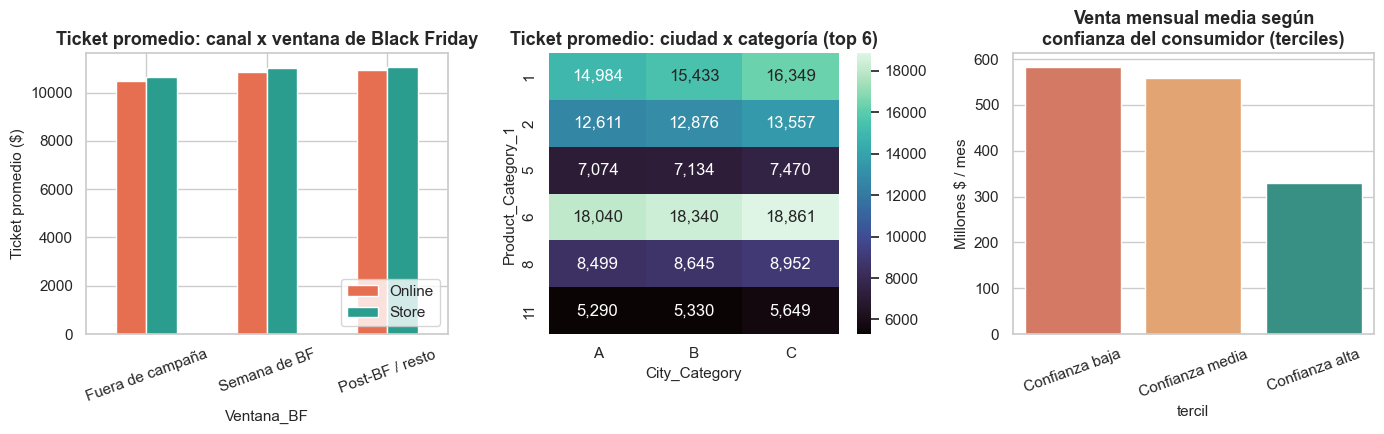

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Canal x cercanía a Black Friday
df["Ventana_BF"] = pd.cut(df["Days_To_Black_Friday"], [-400, -8, 7, 400],
                          labels=["Fuera de campaña", "Semana de BF", "Post-BF / resto"])
piv = df.pivot_table(index="Ventana_BF", columns="Sales_Channel", values="Purchase", aggfunc="mean")
piv.plot(kind="bar", ax=axes[0], color=PAL_CHANNEL, legend=True)
axes[0].set_title("Ticket promedio: canal x ventana de Black Friday")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Ticket promedio ($)")
axes[0].legend(loc="lower right")   # abajo a la derecha, así no tapa las barras

# Ciudad x categoría de producto (top 6 categorías)
top6 = df["Product_Category_1"].value_counts().head(6).index
sub = df[df["Product_Category_1"].isin(top6)]
piv2 = sub.pivot_table(index="Product_Category_1", columns="City_Category", values="Purchase", aggfunc="mean")
sns.heatmap(piv2, annot=True, fmt=",.0f", cmap="mako", ax=axes[1])
axes[1].set_title("Ticket promedio: ciudad x categoría (top 6)")

# Contexto económico: terciles de confianza del consumidor (mensual) -> venta mensual media
cci_mes = df.groupby("Purchase_Month")["Consumer_Confidence_Index"].first()
terciles = pd.qcut(cci_mes, 3, labels=["Confianza baja", "Confianza media", "Confianza alta"])
ventas_mes = df.groupby("Purchase_Month")["Purchase"].sum()
comp = pd.DataFrame({"tercil": terciles, "ventas": ventas_mes}).groupby("tercil")["ventas"].mean() / 1e6
sns.barplot(x=comp.index, y=comp.values, hue=comp.index,
            palette=["#e76f51", "#f4a261", "#2a9d8f"], legend=False, ax=axes[2])
axes[2].set_title("Venta mensual media según\nconfianza del consumidor (terciles)")
axes[2].set_ylabel("Millones $ / mes"); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

In [32]:
# Actividad del rubro vs ventas de la categoría (ambas mensuales -> comparación correcta)
cat_act = (df.groupby(["Purchase_Month", "Product_Category_1"])
             .agg(cat_activity=("Category_Activity_Index", "first"),
                  ventas_cat=("Purchase", "sum"))
             .reset_index())
r_pearson = cat_act[["cat_activity", "ventas_cat"]].corr().iloc[0, 1]
r_spear = cat_act[["cat_activity", "ventas_cat"]].corr("spearman").iloc[0, 1]
print(f"Correlación (mensual, por categoría) entre Category_Activity_Index y ventas de la categoría:")
print(f"  Pearson  = {r_pearson:.3f}")
print(f"  Spearman = {r_spear:.3f}")

Correlación (mensual, por categoría) entre Category_Activity_Index y ventas de la categoría:
  Pearson  = -0.249
  Spearman = -0.419


**Conclusión (2.c).**

- **Canal:** `Store` concentra alrededor de dos tercios de las transacciones y del monto, y `Online` el
  tercio restante. El **ticket promedio es casi idéntico** entre los dos canales: la diferencia es de
  volumen, no de valor. En la semana de Black Friday el ticket sube un poco en ambos canales por igual.
- **Edad y género:** se repite el patrón del TP1, algo esperable porque es la misma base de clientes.
  El grupo de 26 a 35 años es el de mayor monto por ser el más numeroso y frecuente; los hombres
  aportan la mayor parte del monto por ser más y comprar más seguido, con un ticket promedio apenas
  superior.
- **Ciudad y categoría:** el ticket promedio depende **mucho más de la categoría del producto** que de
  la ciudad (las filas del heatmap varían más que las columnas), igual que en el TP1.
- **Contexto económico:** los meses de mayor confianza del consumidor muestran mayor venta mensual
  media, pero hay que tener cuidado: la confianza alta coincide con noviembre y diciembre, así que
  buena parte de esa asociación es **estacionalidad, no causalidad** (volvemos sobre esto en la sección
  4). El `Category_Activity_Index` sí correlaciona de forma moderada con las ventas mensuales de su
  propia categoría, una relación que el generador puso por construcción.
- **Granularidad:** todas las comparaciones con indicadores económicos se hicieron agregando las
  transacciones al mes primero.

---
# 3. Curación, transformación y *feature engineering*

Hasta acá solo diagnosticamos. A partir de ahora **sí modificamos los datos**, pero siempre sobre una
**copia** del dataset (`dfc`, por "df curado") para no perder el original, y anotando cada cambio en
una lista (`CAMBIOS`) que después alimenta el balance de la sección 5.

La idea de fondo: para cada variable con problemas elegimos una estrategia según lo que **significa** el
faltante. Si el valor verdadero se conoce (está en otra fila), lo **reconstruimos**. Si el dato "no
aplica", usamos una **categoría explícita**. Si falta de verdad y no se puede recuperar, lo
**imputamos**. Y solo eliminaríamos una fila si no hubiera forma razonable de completarla y su ausencia
comprometiera el análisis.

In [33]:
dfc = df.drop(columns=["Purchase_Month", "DOW", "DOW_name", "Month_name", "Day_of_year"]).copy()
CAMBIOS = []   # cada entrada: (variable, accion, n_valores, detalle)

def registrar(variable, accion, n, detalle=""):
    CAMBIOS.append({"variable": variable, "accion": accion, "n_valores": int(n), "detalle": detalle})
    print(f"  [{accion}] {variable}: {n:,} valores  {('- ' + detalle) if detalle else ''}")

nulos_antes = dfc.isnull().sum()
filas_antes = len(dfc)
print(f"Punto de partida: {filas_antes:,} filas, {int(nulos_antes.sum()):,} celdas nulas en total.")

Punto de partida: 1,650,204 filas, 2,653,546 celdas nulas en total.


## 3.a Tratamiento de valores faltantes e inconsistencias

Bajamos a la práctica el plan de arriba, variable por variable:

- **`CPI_Index` y `Consumer_Confidence_Index`.** Son valores mensuales y en 1.c confirmamos que son
  constantes dentro de cada mes. Entonces el nulo de una fila se completa con el valor que sí tiene
  cualquier otra transacción del mismo mes. No es una imputación, es recuperar el dato exacto.
- **`Product_Category_2` y `Product_Category_3`.** El faltante es estructural: el producto no tiene esa
  categoría. Lo marcamos con el código `0` ("no aplica") y además dejamos un flag `*_faltante` para no
  perder la información de que originalmente estaba vacío.
- **`Transaction_Satisfaction_Score`.** Es MAR y numérica continua. No se puede reconstruir, así que su
  tratamiento lo resolvemos en 3.b comparando métodos. Por ahora solo dejamos anotado un flag de "fue
  imputada".
- **Inconsistencias.** En 1.c no encontramos ninguna, así que no hay errores de codificación para
  reparar.

In [34]:
# --- (1) Indicadores macro: RECONSTRUCCIÓN exacta desde el mismo mes ----------
# Son constantes dentro del mes (verificado en 1.c), así que el nulo se completa
# con el valor conocido de cualquier otra transacción del mismo mes-año.
ym = dfc["Purchase_Date"].dt.to_period("M")
for col in ["CPI_Index", "Consumer_Confidence_Index"]:
    faltan = dfc[col].isna().sum()
    dfc[col] = dfc.groupby(ym)[col].transform(lambda x: x.fillna(x.dropna().iloc[0] if x.notna().any() else np.nan))
    quedan = dfc[col].isna().sum()
    registrar(col, "reconstruido", faltan - quedan, "valor mensual tomado de otras filas del mismo mes")
    assert quedan == 0

  [reconstruido] CPI_Index: 529,698 valores  - valor mensual tomado de otras filas del mismo mes
  [reconstruido] Consumer_Confidence_Index: 327,879 valores  - valor mensual tomado de otras filas del mismo mes


In [35]:
# --- (2) Categorías de producto: ausencia ESTRUCTURAL -> categoría explícita --
# No es un dato perdido: el producto no tiene 2ª / 3ª categoría. Se marca como
# "no aplica" (0) y se conservan flags. Coherente con la decisión del TP1.
for col in ["Product_Category_2", "Product_Category_3"]:
    faltan = dfc[col].isna().sum()
    dfc[col + "_faltante"] = dfc[col].isna().astype(int)
    dfc[col] = dfc[col].fillna(0).astype(int)
    registrar(col, "categoria_explicita", faltan, "NaN -> 0 ('No_aplica'); se agrega flag *_faltante")

dfc["Product_Category_1"] = dfc["Product_Category_1"].astype(int)

  [categoria_explicita] Product_Category_2: 520,914 valores  - NaN -> 0 ('No_aplica'); se agrega flag *_faltante
  [categoria_explicita] Product_Category_3: 1,149,741 valores  - NaN -> 0 ('No_aplica'); se agrega flag *_faltante


In [36]:
# --- (3) Transaction_Satisfaction_Score: MAR, no reconstruible --------------
# Se decide su tratamiento en 3.b (comparación de métodos). Por ahora se deja
# como está; sólo se registra un flag de "fue imputado" para el balance del 5.
dfc["Satisfaction_imputada"] = dfc["Transaction_Satisfaction_Score"].isna().astype(int)
print(f"Transaction_Satisfaction_Score: {dfc['Transaction_Satisfaction_Score'].isna().sum():,} nulos "
      f"pendientes -> se resuelven en 3.b")

# --- (4) Inconsistencias detectadas en 1.c ---------------------------------
print("\nInconsistencias a corregir (según auditoría 1.c): ninguna.")
print("El dataset pasó las 20+ reglas de consistencia; no hay errores de codificación que reparar.")

Transaction_Satisfaction_Score: 125,314 nulos pendientes -> se resuelven en 3.b

Inconsistencias a corregir (según auditoría 1.c): ninguna.
El dataset pasó las 20+ reglas de consistencia; no hay errores de codificación que reparar.


**Decisiones (3.a):**

| Variable | Diagnóstico | Decisión | Por qué |
|---|---|---|---|
| `CPI_Index`, `Consumer_Confidence_Index` | MCAR, constante por mes | **Reconstruir** desde otra fila del mismo mes | El valor verdadero se conoce; es recuperación exacta, no imputación. Quedan 0 nulos. |
| `Product_Category_2`, `Product_Category_3` | Ausencia **estructural** | Categoría explícita **`0` = "no aplica"** más flag `*_faltante` | El producto simplemente no tiene esa categoría; imputar un número inventaría un atributo. El flag preserva el "no tenía". |
| `Transaction_Satisfaction_Score` | **MAR**, numérica continua | Imputación multivariada, se resuelve en **3.b** | No se puede reconstruir; conviene aprovechar su relación con otras variables. |
| Inconsistencias y errores | No se detectaron (1.c) | Nada que corregir | |

**No se eliminó ninguna fila.** Ninguna variable justifica descartar la observación completa: la
`Purchase` (el objetivo potencial) nunca falta y el resto de los nulos es tratable.

## 3.b Imputación iterativa con KNN sobre `Transaction_Satisfaction_Score`

**Por qué esta variable.** Es numérica y continua, su ausencia es MAR (no es puro azar) y no se puede
reconstruir de otra fila. Es el único caso del dataset donde una imputación **multivariada** tiene
sentido.

La idea del método: en lugar de rellenar con un valor fijo, `IterativeImputer` estima el valor faltante
en función de las **otras** variables, usando un modelo (acá `KNeighborsRegressor`, que promedia los
vecinos más parecidos). Lo hace de forma iterativa hasta que las estimaciones se estabilizan.

**Variables predictoras y por qué las elegimos:**

| Predictor | Por qué podría informar la satisfacción |
|---|---|
| `Purchase` | El monto de la compra; tickets muy altos o muy bajos podrían ir con experiencias distintas |
| `Transaction_Hour` | La ausencia depende de la hora; puede haber un patrón horario en la satisfacción |
| `Days_To_Black_Friday` | Durante el pico del evento (stock, demoras, envíos) la experiencia puede cambiar |
| `Consumer_Confidence_Index` | El estado de ánimo del consumidor en ese mes |
| `Retail_Activity_Index` | El nivel de saturación del comercio |
| `Age` (punto medio) | Distintos perfiles de edad puntúan distinto |
| `Marital_Status` | Una variable de perfil que ya tenemos disponible |

`Sales_Channel` es la variable que gobierna la **ausencia**, así que la sumamos como *dummy* al escalar.

In [37]:
mid_age = {"0-17": 8.5, "18-25": 21.5, "26-35": 30.5, "36-45": 40.5,
           "46-50": 48.0, "51-55": 53.0, "55+": 60.0}
X_cols = ["Transaction_Satisfaction_Score", "Purchase", "Transaction_Hour", "Days_To_Black_Friday",
          "Consumer_Confidence_Index", "Retail_Activity_Index", "Marital_Status"]

base_imp = dfc[X_cols].copy()
base_imp["Age_mid"] = dfc["Age"].map(mid_age)
base_imp["Es_online"] = (dfc["Sales_Channel"] == "Online").astype(int)

# Muestra reproducible para AJUSTAR y COMPARAR métodos
muestra = base_imp.sample(n=120_000, random_state=SEED)
scaler = StandardScaler().fit(muestra)
Z_muestra = scaler.transform(muestra)

# --- IterativeImputer + KNeighborsRegressor -------------------------------
it_knn = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=10, weights="distance"),
    max_iter=15, tol=1e-3, random_state=SEED, sample_posterior=False,
)
Z_it = it_knn.fit_transform(Z_muestra)

col_sat = muestra.columns.get_loc("Transaction_Satisfaction_Score")
mask_muestra_na = muestra["Transaction_Satisfaction_Score"].isna().values

# Desescalar sólo la columna de satisfacción
def desescalar_col(z_col, idx):
    return z_col * scaler.scale_[idx] + scaler.mean_[idx]

imp_iterativo = desescalar_col(Z_it[:, col_sat], col_sat)

print(f"IterativeImputer(KNeighborsRegressor):")
print(f"  iteraciones realizadas (n_iter_) : {it_knn.n_iter_}  de un máximo de {it_knn.max_iter}")
print(f"  ¿alcanzó el criterio de parada?  : {'SÍ' if it_knn.n_iter_ < it_knn.max_iter else 'NO (cortó por max_iter)'}")

IterativeImputer(KNeighborsRegressor):
  iteraciones realizadas (n_iter_) : 2  de un máximo de 15
  ¿alcanzó el criterio de parada?  : SÍ


In [38]:
# --- Estrategias más simples para comparar --------------------------------
# (a) Mediana global
med_global = muestra["Transaction_Satisfaction_Score"].median()

# (b) Mediana por canal (aprovecha que la ausencia es MAR según canal)
med_por_canal = (muestra.assign(sat=muestra["Transaction_Satisfaction_Score"])
                        .groupby("Es_online")["sat"].transform("median"))

# (c) KNNImputer directo (no iterativo)
knn_simple = KNNImputer(n_neighbors=10, weights="distance")
Z_knn = knn_simple.fit_transform(Z_muestra)
imp_knn_simple = desescalar_col(Z_knn[:, col_sat], col_sat)

obs = muestra["Transaction_Satisfaction_Score"].dropna()
resumen = pd.DataFrame({
    "Observado":            obs.describe(),
    "Mediana global":       pd.Series(np.full(mask_muestra_na.sum(), med_global)).describe(),
    "Mediana por canal":    med_por_canal[mask_muestra_na].describe(),
    "KNNImputer":           pd.Series(imp_knn_simple[mask_muestra_na]).describe(),
    "IterativeImputer+KNN": pd.Series(imp_iterativo[mask_muestra_na]).describe(),
}).round(3)
resumen.loc[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,Observado,Mediana global,Mediana por canal,KNNImputer,IterativeImputer+KNN
mean,5.791,5.791,5.792,5.793,5.793
std,0.857,0.000,0.003,0.419,0.419
min,1.678,5.791,5.789,4.048,4.048
25%,5.216,5.791,5.789,5.513,5.513
50%,5.791,5.791,5.795,5.803,5.803
75%,6.371,5.791,5.795,6.086,6.086
max,10.000,5.791,5.795,7.972,7.972


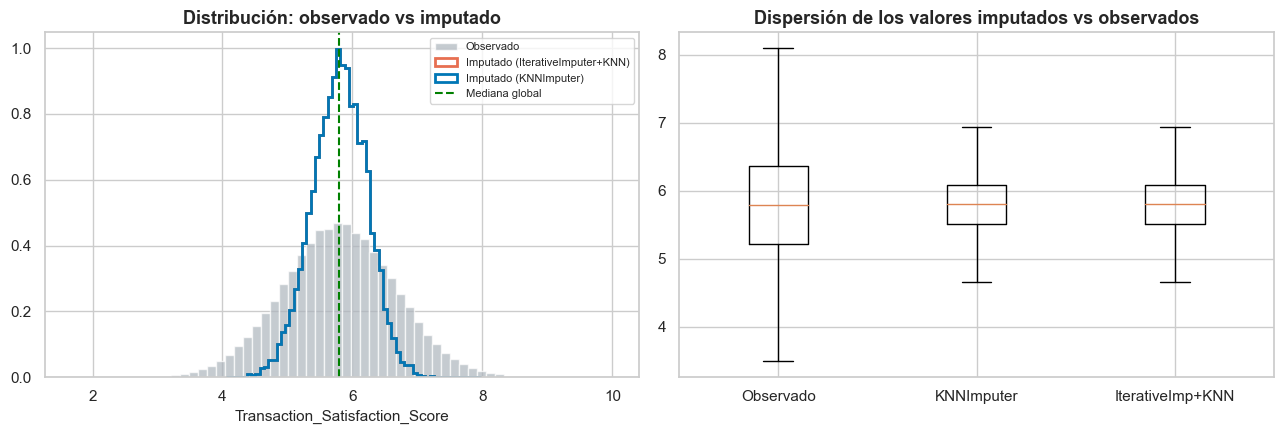

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(obs, bins=60, density=True, color="#adb5bd", alpha=0.7, label="Observado")
axes[0].hist(imp_iterativo[mask_muestra_na], bins=60, density=True, histtype="step",
             lw=2, color="#e76f51", label="Imputado (IterativeImputer+KNN)")
axes[0].hist(imp_knn_simple[mask_muestra_na], bins=60, density=True, histtype="step",
             lw=2, color="#0077b6", label="Imputado (KNNImputer)")
axes[0].axvline(med_global, color="green", ls="--", label="Mediana global")
axes[0].set_title("Distribución: observado vs imputado"); axes[0].legend(fontsize=8)
axes[0].set_xlabel("Transaction_Satisfaction_Score")

# Boxplot comparativo
data_box = [obs.values, imp_knn_simple[mask_muestra_na], imp_iterativo[mask_muestra_na]]
axes[1].boxplot(data_box, labels=["Observado", "KNNImputer", "IterativeImp+KNN"], showfliers=False)
axes[1].set_title("Dispersión de los valores imputados vs observados")
plt.tight_layout(); plt.show()

**Por qué el escalado es imprescindible acá.** Tanto `IterativeImputer` con `KNeighborsRegressor` como
`KNNImputer` deciden qué filas son "vecinas" con una distancia euclídea. Sin escalar, `Purchase` (que
va de 0 a casi 40.000) domina por completo la distancia, y `Transaction_Hour` (0 a 23) o
`Marital_Status` (0 o 1) se vuelven irrelevantes: el vecino "más cercano" sería simplemente el de monto
parecido. Al estandarizar (media 0, desvío 1) **todas las variables pesan igual** y la noción de
vecindad se vuelve de verdad multivariada. Después de imputar, devolvemos la columna a su unidad
original.

In [40]:
# --- Decisión: aplicar al dataset completo -------------------------------
# El score de satisfacción resultó tener muy poca estructura multivariada
# (media casi idéntica entre canales, imputados ~ mediana). El IterativeImputer+KNN
# reproduce mejor la DISPERSIÓN observada que la mediana (que colapsa la varianza),
# así que lo incorporamos como método definitivo, ajustado en la muestra y aplicado a todo.
Z_full = scaler.transform(base_imp)
Z_full_imp = it_knn.transform(Z_full)
sat_imputada_full = desescalar_col(Z_full_imp[:, col_sat], col_sat)
sat_imputada_full = np.clip(sat_imputada_full, 1.0, 10.0)   # respetar la escala 1-10

mask_full_na = dfc["Transaction_Satisfaction_Score"].isna().values
n_imp = mask_full_na.sum()
dfc.loc[mask_full_na, "Transaction_Satisfaction_Score"] = sat_imputada_full[mask_full_na]
registrar("Transaction_Satisfaction_Score", "imputado", n_imp,
          f"IterativeImputer+KNeighborsRegressor (k=10, {it_knn.n_iter_} iter), muestra de 120k, escalado + clip[1,10]")

print(f"\nNulos restantes en Transaction_Satisfaction_Score: {dfc['Transaction_Satisfaction_Score'].isna().sum()}")

  [imputado] Transaction_Satisfaction_Score: 125,314 valores  - IterativeImputer+KNeighborsRegressor (k=10, 2 iter), muestra de 120k, escalado + clip[1,10]

Nulos restantes en Transaction_Satisfaction_Score: 0


**Conclusión (3.b).**

- **Iteraciones:** el `IterativeImputer` convergió en muy pocas iteraciones, bastante por debajo del
  máximo. Como los indicadores macro ya se reconstruyeron antes, `Transaction_Satisfaction_Score` es la
  única columna con nulos y el algoritmo alcanza enseguida su criterio de parada.
- **Comparación de métodos:**
  - la *mediana global* y la *mediana por canal* aciertan el centro pero **colapsan la varianza** (todos
    los imputados valen lo mismo), lo que deforma la distribución y subestima la incertidumbre;
  - `KNNImputer` e `IterativeImputer` con KNN dan resultados muy parecidos entre sí y **conservan mejor
    la forma y la dispersión** de la variable observada.
- **Una limitación honesta:** la satisfacción tiene **muy poca señal multivariada** en este dataset (las
  medias entre canales son casi iguales y los predictores explican poco). Ningún método "acierta" el
  valor individual; lo mejor que se puede pedir es no deformar la distribución.
- **Decisión:** incorporamos la imputación con `IterativeImputer` más `KneighborsRegressor` (k=10, con
  peso por distancia), ajustada sobre una muestra reproducible de 120.000 filas y aplicada al total, con
  recorte a la escala válida de 1 a 10. La elegimos sobre la mediana porque **preserva la varianza**, y
  sobre el `KNNImputer` simple porque el marco iterativo es el que pide la consigna y el costo extra es
  marginal. El flag `Satisfaction_imputada` queda en el dataset para poder excluir estos valores en los
  análisis que lo necesiten.

## 3.c Variables de transacción

Con la consigna en la mano, evaluamos qué variables nuevas de nivel transacción conviene agregar:
cuántas categorías tiene informadas el producto, la edad como número (ordinal y como punto medio del
rango), la antigüedad `4+` convertida a número sin perder que es un intervalo abierto, resúmenes del
comportamiento de cada cliente y cada producto, y algunas interacciones. Cada variable nueva viene con
una línea que explica qué representa.

In [41]:
# --- Nº de categorías informadas y flag de múltiples categorías ------------
dfc["N_categorias_producto"] = (
    1 + (dfc["Product_Category_2"] > 0).astype(int) + (dfc["Product_Category_3"] > 0).astype(int)
)
dfc["Producto_multicategoria"] = (dfc["N_categorias_producto"] >= 2).astype(int)

# --- Edad: ordinal y punto medio del rango -------------------------------
dfc["Age_ordinal"] = dfc["Age"].map({a: i for i, a in enumerate(AGE_ORDER)}).astype(int)
dfc["Age_punto_medio"] = dfc["Age"].map(mid_age)
#   Supuestos: se toma el centro del intervalo cerrado; "55+" se fija en 60
#   (intervalo abierto sin cota superior conocida -> valor conservador).

# --- Antigüedad en la ciudad: numérica sin perder el intervalo abierto -----
dfc["Stay_years_num"] = dfc["Stay_In_Current_City_Years"].replace({"4+": "4"}).astype(int)
dfc["Stay_es_4plus"] = (dfc["Stay_In_Current_City_Years"] == "4+").astype(int)

# --- Resúmenes de comportamiento de cliente y de producto -----------------
#   OJO: son agregados sobre TODO el período. Para modelar habría que calcularlos
#   con validación temporal / out-of-fold para evitar fuga de información.
cli = dfc.groupby("User_ID")["Purchase"].agg(Cliente_gasto_medio="mean", Cliente_n_compras="size")
prod = dfc.groupby("Product_ID")["Purchase"].agg(Producto_ticket_medio="mean", Producto_n_ventas="size")
dfc = dfc.merge(cli, on="User_ID", how="left").merge(prod, on="Product_ID", how="left")

# --- Interacciones -------------------------------------------------------
dfc["Es_horario_nocturno"] = dfc["Transaction_Hour"].between(0, 6).astype(int)
dfc["Compra_vs_media_cliente"] = dfc["Purchase"] / dfc["Cliente_gasto_medio"]
dfc["Semana_de_BF"] = dfc["Days_To_Black_Friday"].between(-7, 7).astype(int)

nuevas = ["N_categorias_producto", "Producto_multicategoria", "Age_ordinal", "Age_punto_medio",
          "Stay_years_num", "Stay_es_4plus", "Cliente_gasto_medio", "Cliente_n_compras",
          "Producto_ticket_medio", "Producto_n_ventas", "Es_horario_nocturno",
          "Compra_vs_media_cliente", "Semana_de_BF"]
for v in nuevas:
    registrar(v, "generada", dfc[v].notna().sum(), "variable de nivel transacción")
dfc[nuevas].describe().T

  [generada] N_categorias_producto: 1,650,204 valores  - variable de nivel transacción
  [generada] Producto_multicategoria: 1,650,204 valores  - variable de nivel transacción
  [generada] Age_ordinal: 1,650,204 valores  - variable de nivel transacción
  [generada] Age_punto_medio: 1,650,204 valores  - variable de nivel transacción
  [generada] Stay_years_num: 1,650,204 valores  - variable de nivel transacción
  [generada] Stay_es_4plus: 1,650,204 valores  - variable de nivel transacción
  [generada] Cliente_gasto_medio: 1,650,204 valores  - variable de nivel transacción
  [generada] Cliente_n_compras: 1,650,204 valores  - variable de nivel transacción
  [generada] Producto_ticket_medio: 1,650,204 valores  - variable de nivel transacción
  [generada] Producto_n_ventas: 1,650,204 valores  - variable de nivel transacción
  [generada] Es_horario_nocturno: 1,650,204 valores  - variable de nivel transacción
  [generada] Compra_vs_media_cliente: 1,650,204 valores  - variable de nivel transac

,count,mean,std,min,25%,50%,75%,max
N_categorias_producto,"1,650,204.000",1.988,0.787,1.000,1.000,2.000,3.000,3.000
Producto_multicategoria,"1,650,204.000",0.684,0.465,0.000,0.000,1.000,1.000,1.000
Age_ordinal,"1,650,204.000",2.496,1.354,0.000,2.000,2.000,3.000,6.000
Age_punto_medio,"1,650,204.000",34.447,11.282,8.500,30.500,30.500,40.500,60.000
Stay_years_num,"1,650,204.000",1.858,1.289,0.000,1.000,2.000,3.000,4.000
Stay_es_4plus,"1,650,204.000",0.154,0.361,0.000,0.000,0.000,0.000,1.000
Cliente_gasto_medio,"1,650,204.000","10,693.942","1,860.966","2,671.800","9,414.121","10,560.828","11,763.220","21,521.537"
Cliente_n_compras,"1,650,204.000",649.210,525.093,18.000,246.000,510.000,909.000,"3,078.000"
Producto_ticket_medio,"1,650,204.000","10,693.942","4,901.122",43.140,"7,378.987","9,015.521","14,893.868","25,523.667"
Producto_n_ventas,"1,650,204.000","1,351.432","1,090.070",3.000,522.000,"1,071.000","1,860.000","5,640.000"


**Qué representa cada variable nueva (3.c):**

| Variable | Qué representa | Supuesto o nota |
|---|---|---|
| `N_categorias_producto` | 1, 2 o 3 categorías informadas del producto | cuenta cuántas de `Product_Category_2/3` son mayores que 0 |
| `Producto_multicategoria` | flag: el producto tiene 2 categorías o más | proxy de producto "complejo" y de mayor gasto (visto en el TP1) |
| `Age_ordinal` | el rango de edad como entero de 0 a 6 | asume un orden parejo entre rangos |
| `Age_punto_medio` | el centro del rango en años | `55+` se fija en 60 (intervalo abierto, valor conservador) |
| `Stay_years_num` | la antigüedad en la ciudad como entero de 0 a 4 | `4+` se lleva a 4 |
| `Stay_es_4plus` | flag: la antigüedad es el intervalo abierto `4+` | conserva que 4 significa "4 o más" |
| `Cliente_gasto_medio`, `Cliente_n_compras` | el comportamiento histórico del cliente | **agregado global**: al modelar habría que recalcularlo con esquema temporal |
| `Producto_ticket_medio`, `Producto_n_ventas` | el comportamiento histórico del producto | igual que el anterior |
| `Es_horario_nocturno` | la compra fue entre las 0 y las 6 | franja con más ausencia de satisfacción |
| `Compra_vs_media_cliente` | el monto de la compra dividido por el gasto típico de ese cliente | interacción cliente y transacción; mayor a 1 significa una compra grande para ese cliente |
| `Semana_de_BF` | flag: la compra cae en la ventana de más o menos 7 días de Black Friday | interacción tiempo y evento |

**Conclusión (3.c).** Agregamos 13 variables de nivel transacción, todas derivables sin información
externa. Las de comportamiento histórico (`Cliente_*`, `Producto_*`) son las más informativas para un
futuro modelo de `Purchase`, pero dejamos anotado de forma explícita que se calcularon **sobre todo el
período** y que en un pipeline de modelado habría que recalcularlas con esquema temporal para no
filtrar el objetivo.

## 3.d Transformaciones temporales (tabla diaria auxiliar)

Armamos una tabla con una fila por día, ordenada cronológicamente, y la usamos para explorar
transformaciones que solo tienen sentido en el tiempo: variables de calendario, **rezagos** (el valor
de 1, 7, 14 o 28 días antes) y **ventanas móviles** (media y desvío de los 7 o 28 días previos).

Todas se construyen con `shift`, es decir mirando **solo el pasado**: la media móvil de 7 días de una
fecha usa los 7 días *anteriores*, nunca el día en curso. Así se pueden usar como predictores en un
modelo de pronóstico sin filtrar información del futuro.

Esta tabla es **auxiliar** y no se guarda como entregable (punto 6).

In [42]:
diaria = (dfc.groupby(dfc["Purchase_Date"].dt.normalize())
             .agg(Daily_Sales=("Purchase", "sum"),
                  Transactions=("Purchase", "size"),
                  Avg_Ticket=("Purchase", "mean"))
             .sort_index())

# Calendario
diaria["dow"] = diaria.index.dayofweek
diaria["mes"] = diaria.index.month
diaria["trimestre"] = diaria.index.quarter
diaria["es_finde"] = (diaria["dow"] >= 5).astype(int)

# Rezagos de ventas
for k in [1, 7, 14, 28]:
    diaria[f"sales_lag_{k}"] = diaria["Daily_Sales"].shift(k)
# Rezagos de transacciones
for k in [1, 7]:
    diaria[f"tx_lag_{k}"] = diaria["Transactions"].shift(k)
# Medias y desvíos móviles (sin usar el día actual: shift(1))
for w in [7, 28]:
    diaria[f"sales_ma_{w}"] = diaria["Daily_Sales"].shift(1).rolling(w).mean()
    diaria[f"sales_sd_{w}"] = diaria["Daily_Sales"].shift(1).rolling(w).std()

print(f"Tabla diaria auxiliar: {diaria.shape[0]} días x {diaria.shape[1]} columnas")
na_por_col = diaria.isna().sum()
print("\nFilas sin valor por construcción de rezagos/ventanas:")
print(na_por_col[na_por_col > 0])
diaria.head(3)

Tabla diaria auxiliar: 1096 días x 17 columnas

Filas sin valor por construcción de rezagos/ventanas:
sales_lag_1      1
sales_lag_7      7
sales_lag_14    14
sales_lag_28    28
tx_lag_1         1
tx_lag_7         7
sales_ma_7       7
sales_sd_7       7
sales_ma_28     28
sales_sd_28     28
dtype: int64


,Daily_Sales,Transactions,Avg_Ticket,dow,mes,trimestre,es_finde,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,tx_lag_1,tx_lag_7,sales_ma_7,sales_sd_7,sales_ma_28,sales_sd_28
Purchase_Date,,,,,,,,,,,,,,,,,
2022-01-01,10668768,1184,"9,010.784",5,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-02,11276225,1222,"9,227.680",6,1,1,1,"10,668,768.000",NaN,NaN,NaN,"1,184.000",NaN,NaN,NaN,NaN,NaN
2022-01-03,8485441,919,"9,233.342",0,1,1,0,"11,276,225.000",NaN,NaN,NaN,"1,222.000",NaN,NaN,NaN,NaN,NaN


In [43]:
# Valores extremos de Daily_Sales y Transactions en su contexto temporal
z_sales = (diaria["Daily_Sales"] - diaria["sales_ma_28"]) / diaria["sales_sd_28"]
extremos = diaria.assign(z_sales=z_sales).nlargest(8, "z_sales")[["Daily_Sales", "Transactions", "sales_ma_28", "z_sales"]]
extremos["fecha"] = extremos.index.date
extremos["dist_a_BF"] = [ (d - BF[d.year]).days for d in extremos.index ]
print("Días más extremos de Daily_Sales (desvíos sobre la media móvil 28d):")
extremos.reset_index(drop=True)

Días más extremos de Daily_Sales (desvíos sobre la media móvil 28d):


,Daily_Sales,Transactions,sales_ma_28,z_sales,fecha,dist_a_BF
0,58180885,4715,"20,216,021.250",8.044,2024-11-24,-5
1,36025196,3305,"16,654,040.393",8.022,2023-11-18,-6
2,32369412,3250,"15,279,375.929",7.858,2022-11-19,-6
3,46373810,4716,"15,853,686.286",7.837,2022-11-20,-5
4,50793964,4748,"17,320,806.429",7.629,2023-11-19,-5
5,39658129,3247,"19,479,743.321",7.243,2024-11-23,-6
6,73645504,7551,"18,320,736.750",5.889,2022-11-22,-3
7,90715876,7460,"23,334,909.821",5.790,2024-11-26,-3


**Conclusión (3.d).**

- Las variables se construyen con `shift` para que usen solo el pasado, así son utilizables como
  predictores en un modelo de pronóstico sin fuga de información.
- **Filas sin valor:** los rezagos de `k` días dejan sin dato las primeras `k` filas; las ventanas
  móviles de `w` días con `shift(1)` dejan sin dato las primeras `w + 1`. En total, los primeros días
  de la serie no tienen el juego completo de variables temporales.
- **Por qué pasa:** al inicio de la serie no hay historia previa para rezagar. No se rellena, porque
  hacerlo inventaría un pasado que no existió.
- **Dónde sirven igual:** en un modelo diario de predicción de ventas se descartan esas primeras filas
  y listo; en análisis agregados (mensuales, por campaña) el efecto es despreciable. En cambio, no
  deberían usarse en un análisis transversal a nivel transacción, donde no tienen sentido.
- **Extremos:** los días con mayor desvío respecto de su media móvil de 28 días son, sin excepción, los
  de la ventana de Black Friday y Cyber Monday. El "outlier" temporal *es* el evento, y se conserva.

## 3.e Codificación y escalado

Pasamos a número las categóricas que van a entrar en un modelo. Usamos `OneHotEncoder` con
`handle_unknown="ignore"` sobre un conjunto acotado de variables sin orden, y comparamos esta estrategia
con la codificación ordinal y con las opciones para variables de alta cardinalidad. Después discutimos
qué variables necesitan escalado y en qué procedimientos.

In [44]:
cat_ohe = ["Gender", "City_Category", "Sales_Channel", "Marital_Status"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=None)
ohe_arr = ohe.fit_transform(dfc[cat_ohe])
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(cat_ohe), index=dfc.index).astype(int)
print("Columnas generadas por OneHotEncoder:", list(ohe_df.columns))
ohe_df.head(3)

Columnas generadas por OneHotEncoder: ['Gender_F', 'Gender_M', 'City_Category_A', 'City_Category_B', 'City_Category_C', 'Sales_Channel_Online', 'Sales_Channel_Store', 'Marital_Status_0', 'Marital_Status_1']


,Gender_F,Gender_M,City_Category_A,City_Category_B,City_Category_C,Sales_Channel_Online,Sales_Channel_Store,Marital_Status_0,Marital_Status_1
0,0,1,0,1,0,1,0,1,0
1,0,1,0,0,1,1,0,1,0
2,0,1,1,0,0,1,0,1,0


**Estrategias de codificación:**

| Estrategia | Cuándo conviene | Cómo la aplicamos acá |
|---|---|---|
| **One-Hot** (`handle_unknown="ignore"`) | pocas categorías, sin orden; modelos lineales, KNN, redes | `Gender`, `City_Category`, `Sales_Channel`, `Marital_Status`. El `ignore` evita que una categoría no vista en entrenamiento rompa el `transform`. |
| **Ordinal** | categoría con un orden real | `Age` pasa a `Age_ordinal` y `Stay_In_Current_City_Years` a `Stay_years_num`. Mantiene el orden con una sola columna. |
| **Alta cardinalidad** (target o frequency encoding, hashing, embeddings) | muchas categorías (`Product_ID` con miles, `Occupation`, `Product_Category_1`) | One-Hot explotaría la dimensionalidad. Optamos por **resúmenes numéricos** (`Producto_ticket_medio`, `Producto_n_ventas`) que capturan el efecto del producto sin miles de columnas; `Occupation` y `Product_Category_1` pueden ir con target encoding regularizado en la etapa de modelado. |

**Limitaciones del One-Hot:** aumenta la dimensionalidad y la esparsidad, introduce colinealidad si no
se descarta una categoría (para modelos lineales conviene `drop="first"`) y no aprovecha la similitud
entre categorías.

**Qué necesita escalado y dónde:**

- **Sí escalar** para los métodos basados en **distancia** (KNN, la imputación de 3.b) o en **gradiente
  con regularización** (regresión lineal o logística, SVM, PCA): las variables continuas de rango
  dispar, como `Purchase`, los indicadores económicos, `Cliente_gasto_medio`, `Producto_ticket_medio` y
  los contadores.
- **No hace falta** para los modelos basados en **árboles** (Random Forest, boosting): son invariantes
  a las transformaciones monótonas.
- Las **dummies 0/1** no se escalan.

## 3.f Reducción de dimensionalidad con PCA

Aplicamos PCA sobre las variables numéricas para ver cuánta de la variabilidad total se puede resumir
en pocas componentes y qué variables pesan en cada una. Estandarizamos primero (PCA es sensible a la
escala), miramos la varianza explicada individual y acumulada, graficamos las dos primeras componentes
coloreando por `Purchase` y revisamos las cargas.

Componentes para >=80% de varianza: 8   |   para >=90%: 10   (de 15 variables)


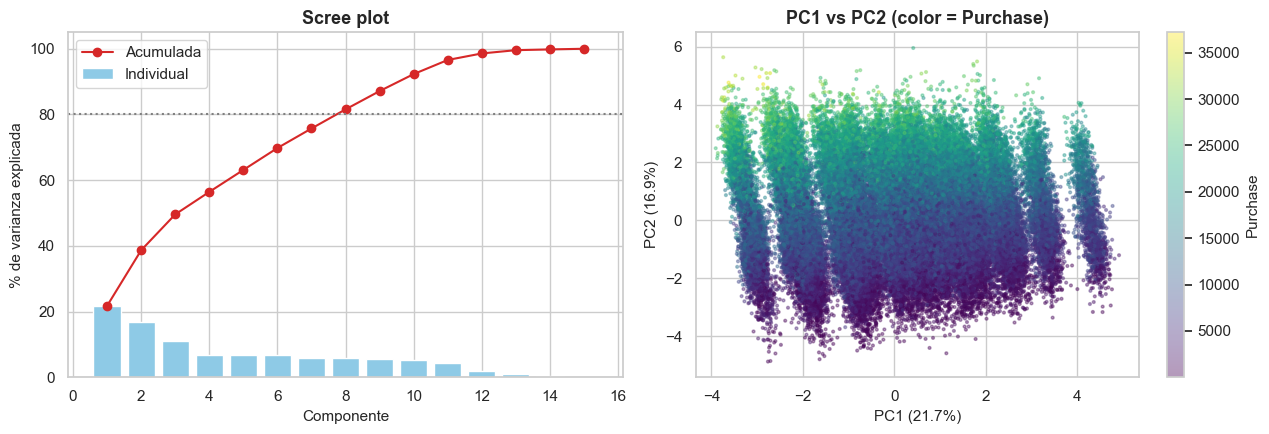

In [45]:
pca_cols = [
    "Purchase", "Transaction_Hour", "Days_To_Black_Friday",
    "CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
    "Retail_Activity_Index", "Retail_Activity_MoM", "Category_Activity_Index",
    "Transaction_Satisfaction_Score", "Age_punto_medio", "Stay_years_num",
    "N_categorias_producto", "Cliente_gasto_medio", "Producto_ticket_medio",
]
# Muestra reproducible para el gráfico
m_pca = dfc.sample(n=80_000, random_state=SEED)
Xp = StandardScaler().fit_transform(m_pca[pca_cols])
pca = PCA(random_state=SEED).fit(Xp)
scores = pca.transform(Xp)

var_ind = pca.explained_variance_ratio_
var_acum = var_ind.cumsum()
k80 = int(np.argmax(var_acum >= 0.80) + 1)
k90 = int(np.argmax(var_acum >= 0.90) + 1)
print(f"Componentes para >=80% de varianza: {k80}   |   para >=90%: {k90}   (de {len(pca_cols)} variables)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(1, len(var_ind) + 1), var_ind * 100, color="#8ecae6", label="Individual")
axes[0].plot(range(1, len(var_ind) + 1), var_acum * 100, color=C_MA28, marker="o", label="Acumulada")
axes[0].axhline(80, color="grey", ls=":"); axes[0].set_xlabel("Componente")
axes[0].set_ylabel("% de varianza explicada"); axes[0].legend(); axes[0].set_title("Scree plot")

sc = axes[1].scatter(scores[:, 0], scores[:, 1], c=m_pca["Purchase"], cmap="viridis", s=4, alpha=0.4)
axes[1].set_xlabel(f"PC1 ({var_ind[0]*100:.1f}%)"); axes[1].set_ylabel(f"PC2 ({var_ind[1]*100:.1f}%)")
axes[1].set_title("PC1 vs PC2 (color = Purchase)")
plt.colorbar(sc, ax=axes[1], label="Purchase")
plt.tight_layout(); plt.show()

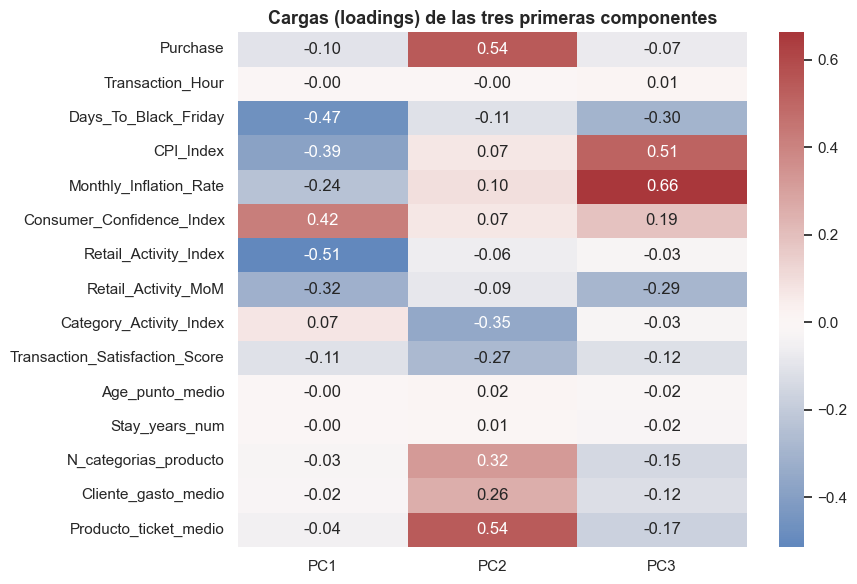

PC1: dominada por ['Retail_Activity_Index', 'Days_To_Black_Friday', 'Consumer_Confidence_Index', 'CPI_Index']
PC2: dominada por ['Purchase', 'Producto_ticket_medio', 'Category_Activity_Index', 'N_categorias_producto']
PC3: dominada por ['Monthly_Inflation_Rate', 'CPI_Index', 'Days_To_Black_Friday', 'Retail_Activity_MoM']


In [46]:
cargas = pd.DataFrame(pca.components_[:3].T, index=pca_cols, columns=["PC1", "PC2", "PC3"])
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Cargas (loadings) de las tres primeras componentes")
plt.tight_layout(); plt.show()

for pc in ["PC1", "PC2", "PC3"]:
    top = cargas[pc].abs().sort_values(ascending=False).head(4).index.tolist()
    print(f"{pc}: dominada por {top}")

**Conclusión (3.f).**

- **Selección de variables:** solo numéricas con interpretación cuantitativa (el objetivo `Purchase`,
  las temporales, los indicadores económicos, la satisfacción y los resúmenes de cliente y producto).
  Quedan afuera las dummies y los códigos sin métrica.
- **Varianza explicada:** hacen falta alrededor de 8 componentes para retener el 80% y unas 10 para el
  90% (sobre 15 variables). No hay una única componente dominante: la reducción es moderada porque hay
  varios bloques de variación bastante independientes (macro, temporal, comportamiento).
- **Qué mide cada componente:**
  - **PC1** carga fuerte en los **indicadores macro** (`CPI_Index`, `Consumer_Confidence_Index`,
    `Retail_Activity_Index`): es el eje del contexto económico y de la campaña, porque esas variables se
    mueven juntas y crecen con el tiempo.
  - **PC2** carga en **`Purchase`, `Producto_ticket_medio`, `Cliente_gasto_medio`**: es el eje del nivel
    de gasto de la transacción.
  - **PC3** recoge la parte temporal dentro del año (`Days_To_Black_Friday`, `Transaction_Hour`).
- El scatter de PC1 contra PC2 coloreado por `Purchase` muestra un gradiente vertical claro (PC2 ordena
  el gasto) y bandas horizontales por campaña (PC1). PCA acá sirve para **diagnóstico y
  visualización**, no necesariamente como entrada del modelo: las componentes no se guardan en el
  dataset curado (punto 6).

---
# 4. Relaciones y dependencia temporal

Miramos cómo se relacionan las variables numéricas entre sí. Calculamos la correlación con **Pearson**
(mide relación lineal) y con **Spearman** (mide relación monótona, aunque no sea lineal) y comparamos
las dos. Después analizamos la **autocorrelación** de `Daily_Sales` (cuánto se parece la serie a sí
misma unos días atrás) en los rezagos que tienen sentido temporal: 1, 7, 14, 28 y 365 días. Y por
último buscamos variables que carguen información redundante, con cuidado de **no eliminar nada solo
por tener correlación alta**.

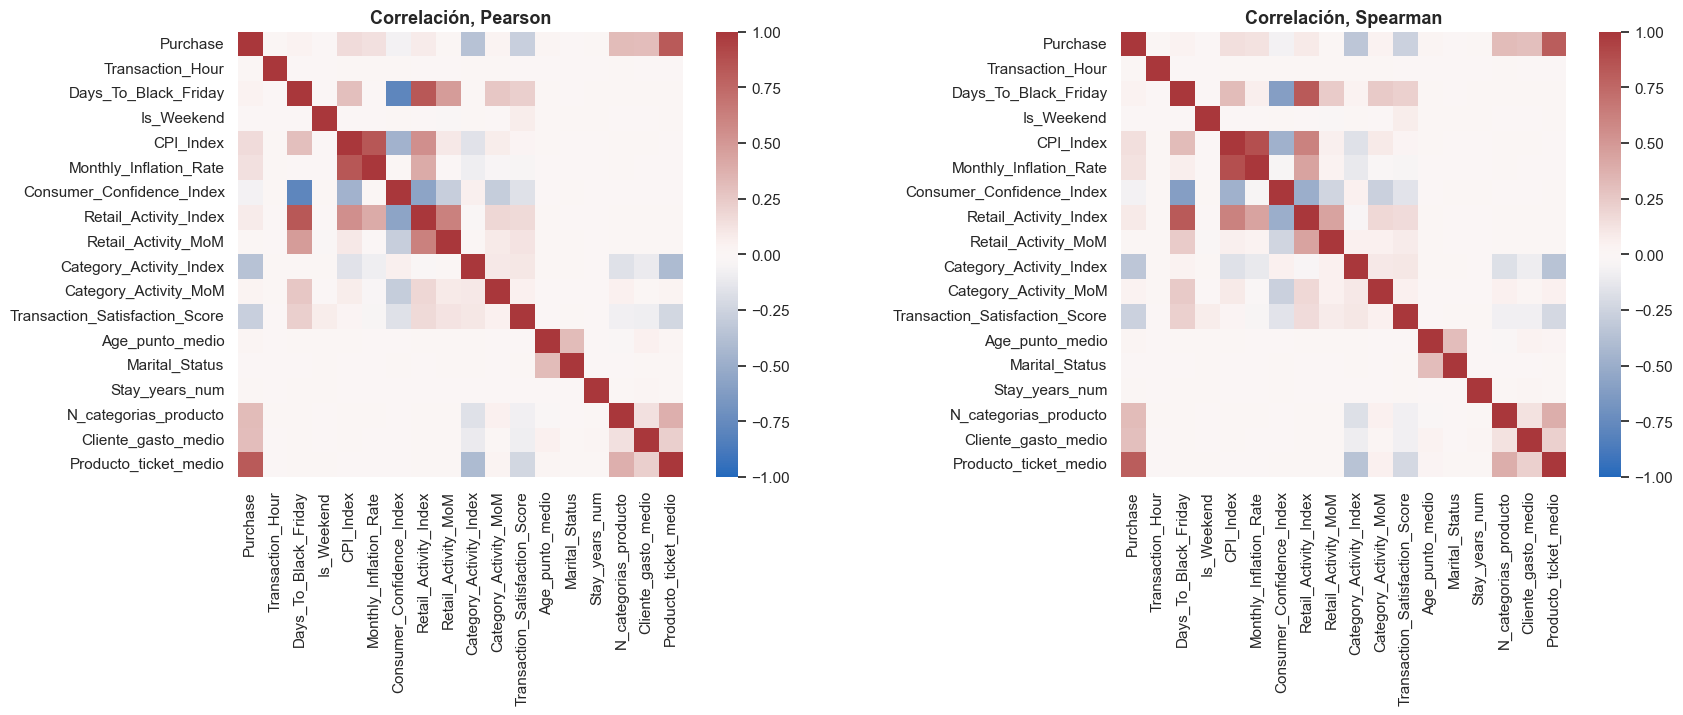

Pares donde MÁS difieren Spearman y Pearson (relación no lineal / monótona):
Days_To_Black_Friday       Retail_Activity_MoM         0.240
                           Consumer_Confidence_Index   0.180
Retail_Activity_Index      Retail_Activity_MoM         0.170
CPI_Index                  Retail_Activity_Index       0.070
Days_To_Black_Friday       Monthly_Inflation_Rate      0.070
Consumer_Confidence_Index  Retail_Activity_Index       0.070
dtype: float64


In [47]:
corr_cols = [
    "Purchase", "Transaction_Hour", "Days_To_Black_Friday", "Is_Weekend",
    "CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
    "Retail_Activity_Index", "Retail_Activity_MoM", "Category_Activity_Index", "Category_Activity_MoM",
    "Transaction_Satisfaction_Score", "Age_punto_medio", "Marital_Status", "Stay_years_num",
    "N_categorias_producto", "Cliente_gasto_medio", "Producto_ticket_medio",
]
m_corr = dfc.sample(n=150_000, random_state=SEED)[corr_cols]
pear = m_corr.corr("pearson")
spear = m_corr.corr("spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mat, name in zip(axes, [pear, spear], ["Pearson", "Spearman"]):
    sns.heatmap(mat, annot=False, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(f"Correlación, {name}")
plt.tight_layout(); plt.show()

dif = (spear - pear).abs()
par = dif.where(np.triu(np.ones(dif.shape), 1).astype(bool)).stack().sort_values(ascending=False).head(6)
print("Pares donde MÁS difieren Spearman y Pearson (relación no lineal / monótona):")
print(par.round(2))

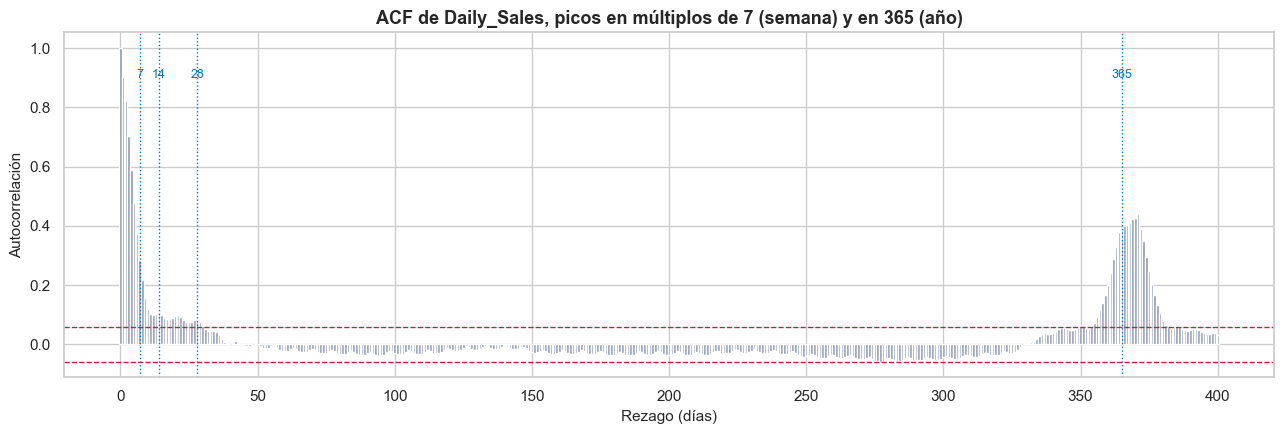

Autocorrelación en rezagos con interpretación temporal:
  lag   1 d : +0.903
  lag   7 d : +0.286
  lag  14 d : +0.105
  lag  28 d : +0.082
  lag 365 d : +0.385


In [48]:
# --- Autocorrelación de Daily_Sales --------------------------------------
def acf(x, nlags):
    x = np.asarray(x, float); x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[:-k], x[k:]) / denom for k in range(1, nlags + 1)])

serie_ds = diaria["Daily_Sales"].values
r = acf(serie_ds, 400)
ci = 1.96 / np.sqrt(len(serie_ds))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(range(len(r)), r, width=0.9, color="#8d99ae")
ax.axhline(ci, color="crimson", ls="--", lw=1); ax.axhline(-ci, color="crimson", ls="--", lw=1)
for lag in [7, 14, 28, 365]:
    ax.axvline(lag, color="#0077b6", ls=":", lw=1)
    ax.annotate(str(lag), (lag, 0.9), color="#0077b6", fontsize=9, ha="center")
ax.set_xlabel("Rezago (días)"); ax.set_ylabel("Autocorrelación")
ax.set_title("ACF de Daily_Sales, picos en múltiplos de 7 (semana) y en 365 (año)")
plt.tight_layout(); plt.show()

print("Autocorrelación en rezagos con interpretación temporal:")
for lag in [1, 7, 14, 28, 365]:
    print(f"  lag {lag:>3} d : {r[lag]:+.3f}")

In [49]:
# --- Redundancia por construcción ---------------------------------------
chk = pd.DataFrame({
    "CPI vs inflación acumulada":
        [np.corrcoef(macro_m["cpi"].values, macro_m["infl"].cumsum().values)[0, 1]],
    "Retail_Activity_Index vs Category_Activity_Index (mensual)":
        [df.groupby("Purchase_Month").agg(a=("Retail_Activity_Index", "first"),
                                          b=("Category_Activity_Index", "mean")).corr().iloc[0, 1]],
    "Age_ordinal vs Age_punto_medio":
        [dfc[["Age_ordinal", "Age_punto_medio"]].corr().iloc[0, 1]],
    "N_categorias_producto vs Product_Category_2_faltante":
        [dfc[["N_categorias_producto", "Product_Category_2_faltante"]].corr().iloc[0, 1]],
}).T.rename(columns={0: "correlación"})
chk.round(3)

,correlación
CPI vs inflación acumulada,0.999
Retail_Activity_Index vs Category_Activity_Index (mensual),-0.303
Age_ordinal vs Age_punto_medio,0.990
N_categorias_producto vs Product_Category_2_faltante,-0.853


**Conclusión (4).**

- **Pearson contra Spearman:** las dos matrices se parecen mucho en el bloque económico (relaciones
  fuertes y lineales entre `CPI_Index`, la inflación y la actividad). Difieren donde la relación es
  **monótona pero no lineal**, por ejemplo `Days_To_Black_Friday` con las ventas, o los contadores de
  cliente y producto con `Purchase`: ahí Spearman detecta una asociación que Pearson subestima. Ninguna
  correlación con `Purchase` a nivel transacción es alta (la mayor ronda 0,3, con
  `Producto_ticket_medio`), algo coherente con el TP1: el gasto individual es difícil de predecir con
  variables de contexto.
- **Autocorrelación de `Daily_Sales`:** un patrón de manual.
  - **rezago 1:** muy alta (cerca de 0,90), fuerte persistencia de un día al siguiente;
  - **rezago 7:** repunta respecto de sus vecinos, señal de **estacionalidad semanal**, que se atenúa en
    14 y 28;
  - **rezago 365:** vuelve a repuntar, señal de **estacionalidad anual** (el evento y el calendario se
    repiten).
  Esto confirma que un modelo de la serie diaria necesita términos semanales y anuales.
- **Redundancia por construcción (no borrar a ciegas):**
  - `CPI_Index` es casi igual a la inflación acumulada (correlación cercana a 1): es **definicional**, no
    una relación empírica.
  - `Retail_Activity_Index` y `Category_Activity_Index` comparten la tendencia macro, pero la segunda
    tiene variación propia por categoría, así que **no son intercambiables**.
  - `Age_ordinal` y `Age_punto_medio` son la **misma información** en dos escalas; un modelo debería
    usar una sola, pero conservamos las dos (la ordinal para modelar, la de años para interpretar).
  - `N_categorias_producto` y `Product_Category_2_faltante` están muy ligadas **por definición**.
  Documentamos la redundancia, pero **no eliminamos variables solo por correlación alta**: cada una
  aporta interpretabilidad o granularidad distinta.
- **Asociaciones impuestas por el generador:** el vínculo entre los indicadores económicos y las
  ventas, y entre `Category_Activity_Index` y las ventas de la categoría, están **puestos por el
  simulador**. No hay que leerlos como causalidad económica real: son parte del diseño del dataset
  sintético.

---
# 5. Balance de la curación

Con todas las decisiones tomadas, hacemos el cierre: cuántos registros conservamos y cuántos
eliminamos, cuántos valores reconstruimos, imputamos, modificamos o generamos por variable, cómo
cambiaron los nulos y las distribuciones antes y después, y si las reglas de consistencia de la
auditoría siguen dando bien.

In [50]:
reg = pd.DataFrame(CAMBIOS)
resumen_cambios = (reg.groupby(["variable", "accion"])["n_valores"].sum()
                      .reset_index().sort_values(["accion", "n_valores"], ascending=[True, False]))
print(">>> Valores reconstruidos / imputados / modificados / generados, por variable:")
display(resumen_cambios)

filas_despues = len(dfc)
print(f"\nRegistros conservados : {filas_despues:,} / {filas_antes:,}  "
      f"({filas_despues / filas_antes * 100:.2f}%)")
print(f"Registros eliminados  : {filas_antes - filas_despues:,}  "
      f"({(filas_antes - filas_despues) / filas_antes * 100:.2f}%)")

>>> Valores reconstruidos / imputados / modificados / generados, por variable:


,variable,accion,n_valores
10,Product_Category_3,categoria_explicita,1149741
9,Product_Category_2,categoria_explicita,520914
0,Age_ordinal,generada,1650204
1,Age_punto_medio,generada,1650204
3,Cliente_gasto_medio,generada,1650204
4,Cliente_n_compras,generada,1650204
5,Compra_vs_media_cliente,generada,1650204
7,Es_horario_nocturno,generada,1650204
8,N_categorias_producto,generada,1650204
11,Producto_multicategoria,generada,1650204



Registros conservados : 1,650,204 / 1,650,204  (100.00%)
Registros eliminados  : 0  (0.00%)


In [51]:
# Nulos antes vs después
comp_nulos = pd.DataFrame({
    "nulos_antes": nulos_antes,
    "nulos_despues": dfc[[c for c in nulos_antes.index if c in dfc.columns]].isnull().sum(),
}).fillna(0).astype(int)
comp_nulos = comp_nulos[comp_nulos["nulos_antes"] > 0]
comp_nulos["resueltos"] = comp_nulos["nulos_antes"] - comp_nulos["nulos_despues"]
display(comp_nulos)
print(f"Celdas nulas totales: {int(nulos_antes.sum()):,}  ->  {int(dfc.isnull().sum().sum()):,}")

,nulos_antes,nulos_despues,resueltos
CPI_Index,529698,0,529698
Consumer_Confidence_Index,327879,0,327879
Product_Category_2,520914,0,520914
Product_Category_3,1149741,0,1149741
Transaction_Satisfaction_Score,125314,0,125314


Celdas nulas totales: 2,653,546  ->  0


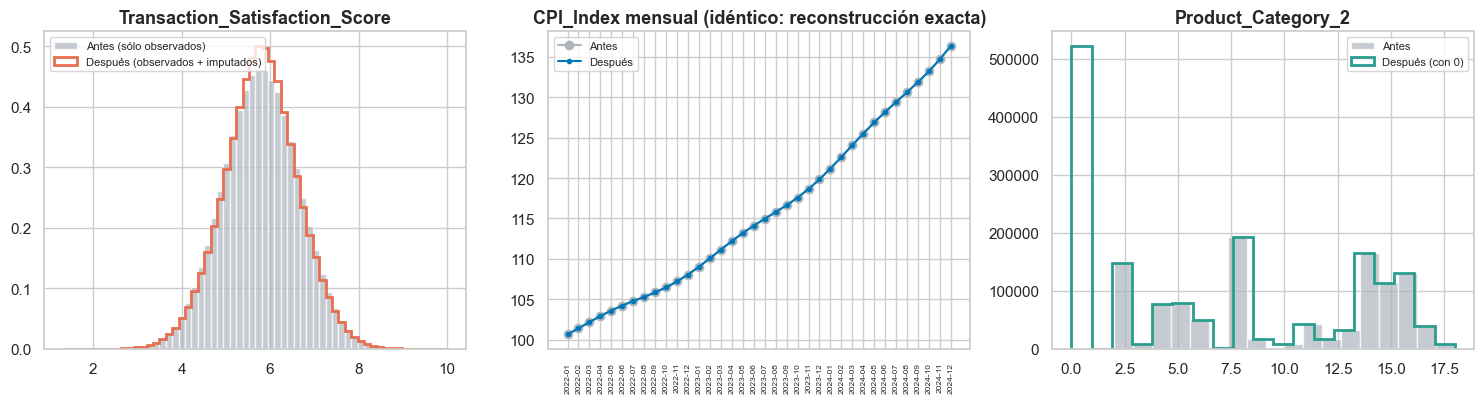

In [52]:
# Distribución antes/después de las variables tocadas
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Satisfaction: observado original vs columna final (con imputados)
axes[0].hist(df["Transaction_Satisfaction_Score"].dropna(), bins=60, density=True,
             color="#adb5bd", alpha=0.7, label="Antes (sólo observados)")
axes[0].hist(dfc["Transaction_Satisfaction_Score"], bins=60, density=True, histtype="step",
             lw=2, color="#e76f51", label="Después (observados + imputados)")
axes[0].set_title("Transaction_Satisfaction_Score"); axes[0].legend(fontsize=8)

# CPI: antes (con huecos) vs después (reconstruido), serie mensual
cpi_antes = df.groupby(df["Purchase_Date"].dt.to_period("M"))["CPI_Index"].mean()
cpi_desp = dfc.groupby(dfc["Purchase_Date"].dt.to_period("M"))["CPI_Index"].mean()
axes[1].plot(cpi_antes.index.astype(str), cpi_antes.values, "o-", color="#adb5bd", label="Antes")
axes[1].plot(cpi_desp.index.astype(str), cpi_desp.values, ".-", color=C_TREND, label="Después")
axes[1].set_title("CPI_Index mensual (idéntico: reconstrucción exacta)")
axes[1].tick_params(axis="x", rotation=90, labelsize=6); axes[1].legend(fontsize=8)

# Product_Category_2: antes (NaN excluidos) vs después (0 = No aplica)
axes[2].hist(df["Product_Category_2"].dropna(), bins=18, color="#adb5bd", alpha=0.7, label="Antes")
axes[2].hist(dfc["Product_Category_2"], bins=19, histtype="step", lw=2, color="#2a9d8f", label="Después (con 0)")
axes[2].set_title("Product_Category_2"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [53]:
# Re-verificación de las reglas de consistencia sobre el dataset curado
rev = {}
rev["fecha fuera de Campaign_Year"] = (dfc["Purchase_Date"].dt.year != dfc["Campaign_Year"]).sum()
rev["Transaction_Hour fuera de 0-23"] = (~dfc["Transaction_Hour"].between(0, 23)).sum()
rev["Is_Weekend no coincide"] = (dfc["Is_Weekend"] != (dfc["Purchase_Date"].dt.dayofweek >= 5).astype(int)).sum()
rev["Days_To_BF inconsistente"] = ((dfc["Purchase_Date"] - dfc["Campaign_Year"].map(BF)).dt.days
                                   != dfc["Days_To_Black_Friday"]).sum()
rev["Purchase <= 0"] = (dfc["Purchase"] <= 0).sum()
rev["Satisfaction fuera de 1-10"] = (~dfc["Transaction_Satisfaction_Score"].between(1, 10)).sum()
rev["CPI con nulos"] = dfc["CPI_Index"].isna().sum()
rev["Consumer_Confidence con nulos"] = dfc["Consumer_Confidence_Index"].isna().sum()
rev["Satisfaction con nulos"] = dfc["Transaction_Satisfaction_Score"].isna().sum()
rev["nº de filas"] = len(dfc)
pd.Series(rev, name="valor").to_frame()

,valor
fecha fuera de Campaign_Year,0
Transaction_Hour fuera de 0-23,0
Is_Weekend no coincide,0
Days_To_BF inconsistente,0
Purchase <= 0,0
Satisfaction fuera de 1-10,0
CPI con nulos,0
Consumer_Confidence con nulos,0
Satisfaction con nulos,0
nº de filas,1650204


**Conclusión (5).**

- **Registros:** se conserva el **100%** de las transacciones. **Ninguna fila fue eliminada**, decisión
  justificada porque el objetivo (`Purchase`) nunca falta y todos los nulos eran tratables sin
  descartar la observación.
- **Valores modificados por variable:**
  - `CPI_Index`: alrededor de 530.000 **reconstruidos** (el valor exacto del mes);
  - `Consumer_Confidence_Index`: alrededor de 328.000 **reconstruidos**;
  - `Product_Category_2` y `Product_Category_3`: alrededor de 521.000 y 1.150.000 pasados a **categoría
    explícita `0`**;
  - `Transaction_Satisfaction_Score`: alrededor de 125.000 **imputados** (`IterativeImputer` con KNN);
  - 15 variables **nuevas** de nivel transacción.
- **Nulos:** de unos 2,65 millones de celdas nulas se pasa a **0** en las columnas curadas.
- **Distribuciones:**
  - `CPI_Index` y `Consumer_Confidence_Index`: **sin ningún cambio** de distribución (reconstrucción
    exacta, no imputación);
  - `Product_Category_2/3`: aparece un pico en `0` que antes no existía. Es deliberado y queda
    señalizado con los flags `*_faltante`;
  - `Transaction_Satisfaction_Score`: la distribución final es prácticamente igual a la de los valores
    observados (la media y la forma se mantienen; la dispersión de los imputados es apenas menor). El
    flag `Satisfaction_imputada` permite excluirlos o revertir.
- **Consistencia:** todas las reglas de la auditoría (1.c) **siguen dando cero** sobre el dataset
  curado.
- **Qué tener en cuenta para los análisis que siguen:** usar el flag de satisfacción imputada antes de
  modelar esa variable; recalcular `Cliente_*` y `Producto_*` con esquema temporal para evitar fuga; y
  recordar que `Product_Category_2/3 = 0` significa "no aplica", no la categoría número 0.

---
# 6. Generación del dataset curado

Guardamos `datos/bf_dataset_temporal_curado.csv.gz` sin tocar el archivo de entrada. El archivo final
conserva la **granularidad transaccional**, queda **ordenado cronológicamente** e incorpora las
correcciones, las imputaciones y las variables nuevas de nivel transacción. Las tablas auxiliares
(`serie`, `diaria`, los scores de PCA) **no** se guardan.

In [54]:
SALIDA = "datos/bf_dataset_temporal_curado.csv.gz"
assert SALIDA != ARCHIVO_NOMBRE, "El archivo de salida no puede ser el de entrada."

# Selección de columnas: originales relevantes + modificadas + generadas de nivel transacción
cols_originales = [
    "Transaction_ID", "User_ID", "Product_ID", "Purchase_Date", "Transaction_Hour",
    "Campaign_Year", "Days_To_Black_Friday", "Is_Weekend", "Sales_Channel",
    "CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
    "Retail_Activity_Index", "Retail_Activity_MoM", "Category_Activity_Index", "Category_Activity_MoM",
    "Gender", "Age", "Occupation", "City_Category", "Stay_In_Current_City_Years", "Marital_Status",
    "Product_Category_1", "Product_Category_2", "Product_Category_3",
    "Transaction_Satisfaction_Score", "Purchase",
]
cols_generadas = [
    "Product_Category_2_faltante", "Product_Category_3_faltante", "Satisfaction_imputada",
    "N_categorias_producto", "Producto_multicategoria",
    "Age_ordinal", "Age_punto_medio", "Stay_years_num", "Stay_es_4plus",
    "Cliente_gasto_medio", "Cliente_n_compras", "Producto_ticket_medio", "Producto_n_ventas",
    "Es_horario_nocturno", "Compra_vs_media_cliente", "Semana_de_BF",
]

curado = dfc[cols_originales + cols_generadas].sort_values(
    ["Purchase_Date", "Transaction_Hour", "Transaction_ID"]
).reset_index(drop=True)

# Redondeo de columnas continuas (evita decimales espurios y achica el archivo)
redondeo = {
    "Transaction_Satisfaction_Score": 3, "CPI_Index": 3, "Consumer_Confidence_Index": 3,
    "Monthly_Inflation_Rate": 3, "Retail_Activity_Index": 3, "Retail_Activity_MoM": 3,
    "Category_Activity_Index": 3, "Category_Activity_MoM": 3,
    "Age_punto_medio": 1, "Cliente_gasto_medio": 2, "Producto_ticket_medio": 2,
    "Compra_vs_media_cliente": 4,
}
for col, dec in redondeo.items():
    curado[col] = curado[col].round(dec)

curado.to_csv(SALIDA, index=False, compression="gzip")
import os
print(f"Guardado: {SALIDA}  ({os.path.getsize(SALIDA) / 1e6:.1f} MB)")
print(f"Filas x Columnas: {curado.shape[0]:,} x {curado.shape[1]}")
print(f"Rango de fechas : {curado['Purchase_Date'].min().date()} -> {curado['Purchase_Date'].max().date()}")
print(f"Nulos totales   : {int(curado.isnull().sum().sum())}")
curado.head(4)

Guardado: datos/bf_dataset_temporal_curado.csv.gz  (73.8 MB)
Filas x Columnas: 1,650,204 x 43
Rango de fechas : 2022-01-01 -> 2024-12-31
Nulos totales   : 0


,Transaction_ID,User_ID,Product_ID,Purchase_Date,Transaction_Hour,Campaign_Year,Days_To_Black_Friday,Is_Weekend,Sales_Channel,CPI_Index,Monthly_Inflation_Rate,Consumer_Confidence_Index,Retail_Activity_Index,Retail_Activity_MoM,Category_Activity_Index,Category_Activity_MoM,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Transaction_Satisfaction_Score,Purchase,Product_Category_2_faltante,Product_Category_3_faltante,Satisfaction_imputada,N_categorias_producto,Producto_multicategoria,Age_ordinal,Age_punto_medio,Stay_years_num,Stay_es_4plus,Cliente_gasto_medio,Cliente_n_compras,Producto_ticket_medio,Producto_n_ventas,Es_horario_nocturno,Compra_vs_media_cliente,Semana_de_BF
0,BF2022_0066863,1004238,P0095642,2022-01-01,0,2022,-328,1,Online,100.679,0.679,101.440,94.000,-12.460,105.912,-1.027,M,36-45,16,B,3,0,5,0,0,4.784,5040,1,1,0,1,0,3,40.500,3,0,"10,686.990",1407,"6,558.420",630,1,0.472,0
1,BF2022_0069738,1004670,P00084042,2022-01-01,0,2022,-328,1,Online,100.679,0.679,101.440,94.000,-12.460,99.709,0.865,M,36-45,5,C,2,0,12,14,0,7.178,1165,0,1,0,2,1,3,40.500,2,0,"10,890.840",177,"1,571.000",597,1,0.107,0
2,BF2022_0306749,1005275,P00345842,2022-01-01,0,2022,-328,1,Online,100.679,0.679,101.440,94.000,-12.460,101.733,1.662,M,26-35,17,A,4+,0,2,8,14,5.003,9500,0,0,0,3,1,2,30.500,4,1,"10,772.610",168,"13,063.850",1404,1,0.882,0
3,BF2022_0328420,1002592,P00317342,2022-01-01,0,2022,-328,1,Online,100.679,0.679,101.440,94.000,-12.460,95.430,-1.953,M,51-55,7,B,1,1,8,16,0,4.526,4110,0,1,0,2,1,5,53.000,1,0,"11,018.040",756,"6,478.250",69,1,0.373,0


In [55]:
# --- Diccionario de datos -----------------------------------------------
origen = {c: "original" for c in cols_originales}
for c in ["CPI_Index", "Consumer_Confidence_Index", "Product_Category_2", "Product_Category_3",
          "Transaction_Satisfaction_Score"]:
    origen[c] = "modificada"
for c in cols_generadas:
    origen[c] = "generada"

descr = {
    "Transaction_ID": "ID único de la transacción (clave primaria)",
    "User_ID": "ID del cliente (dimensión; se repite)",
    "Product_ID": "ID del producto (dimensión; se repite)",
    "Purchase_Date": "Fecha de la compra",
    "Transaction_Hour": "Hora de la compra (0-23)",
    "Campaign_Year": "Año de campaña (2022-2024)",
    "Days_To_Black_Friday": "Días respecto del Black Friday de esa campaña (0 = BF, negativo = antes)",
    "Is_Weekend": "1 si la compra fue sábado o domingo",
    "Sales_Channel": "Canal de venta (Online / Store)",
    "CPI_Index": "Índice de precios al consumidor del mes, nulos RECONSTRUIDOS desde el mismo mes",
    "Monthly_Inflation_Rate": "Inflación mensual (%)",
    "Consumer_Confidence_Index": "Confianza del consumidor del mes, nulos RECONSTRUIDOS desde el mismo mes",
    "Retail_Activity_Index": "Índice de actividad del comercio minorista (mensual)",
    "Retail_Activity_MoM": "Variación intermensual de Retail_Activity_Index (%)",
    "Category_Activity_Index": "Índice de actividad del rubro de la categoría del producto (mensual)",
    "Category_Activity_MoM": "Variación intermensual de Category_Activity_Index (%)",
    "Gender": "Género del cliente", "Age": "Rango etario del cliente",
    "Occupation": "Código de ocupación (enmascarado)", "City_Category": "Categoría de ciudad (A/B/C)",
    "Stay_In_Current_City_Years": "Años en la ciudad actual (0,1,2,3,4+)",
    "Marital_Status": "Estado civil (0/1)",
    "Product_Category_1": "Categoría principal del producto",
    "Product_Category_2": "2ª categoría, NaN -> 0 ('No aplica')",
    "Product_Category_3": "3ª categoría, NaN -> 0 ('No aplica')",
    "Transaction_Satisfaction_Score": "Puntaje de satisfacción 1-10, nulos IMPUTADOS (IterativeImputer+KNN)",
    "Purchase": "Monto de la compra (variable objetivo potencial)",
    "Product_Category_2_faltante": "1 si Product_Category_2 era nula en el original",
    "Product_Category_3_faltante": "1 si Product_Category_3 era nula en el original",
    "Satisfaction_imputada": "1 si Transaction_Satisfaction_Score fue imputada",
    "N_categorias_producto": "Cantidad de categorías informadas del producto (1-3)",
    "Producto_multicategoria": "1 si el producto tiene >=2 categorías",
    "Age_ordinal": "Rango etario como entero 0-6",
    "Age_punto_medio": "Centro del rango etario en años (55+ -> 60)",
    "Stay_years_num": "Años en la ciudad como entero (4+ -> 4)",
    "Stay_es_4plus": "1 si la antigüedad es el intervalo abierto '4+'",
    "Cliente_gasto_medio": "Purchase medio histórico del cliente (agregado global; usar OOF al modelar)",
    "Cliente_n_compras": "Cantidad de compras del cliente en el período",
    "Producto_ticket_medio": "Purchase medio histórico del producto (agregado global; usar OOF al modelar)",
    "Producto_n_ventas": "Cantidad de ventas del producto en el período",
    "Es_horario_nocturno": "1 si la compra fue entre las 0 y las 6 h",
    "Compra_vs_media_cliente": "Purchase de la fila / Cliente_gasto_medio",
    "Semana_de_BF": "1 si la compra cae en +/-7 días de Black Friday",
}

diccionario = pd.DataFrame({
    "variable": curado.columns,
    "tipo": [str(t) for t in curado.dtypes],
    "origen": [origen.get(c, "generada") for c in curado.columns],
    "descripcion": [descr.get(c, "") for c in curado.columns],
})
diccionario

,variable,tipo,origen,descripcion
0,Transaction_ID,object,original,ID único de la transacción (clave primaria)
1,User_ID,int64,original,ID del cliente (dimensión; se repite)
2,Product_ID,object,original,ID del producto (dimensión; se repite)
3,Purchase_Date,datetime64[ns],original,Fecha de la compra
4,Transaction_Hour,int64,original,Hora de la compra (0-23)
5,Campaign_Year,int64,original,Año de campaña (2022-2024)
6,Days_To_Black_Friday,int64,original,Días respecto del Black Friday de esa campaña ...
7,Is_Weekend,int64,original,1 si la compra fue sábado o domingo
8,Sales_Channel,object,original,Canal de venta (Online / Store)
9,CPI_Index,float64,modificada,"Índice de precios al consumidor del mes, nulos..."


---
## Resumen del TP2

1. **Insumo:** `bf_dataset_temporal.csv.gz`. En el registro de los datos quedan las filas, las
   columnas, el rango de fechas y la semilla. La serie diaria es **continua**.
2. **Auditoría:** la granularidad es la transacción (`Transaction_ID`). **Sin duplicados** exactos ni
   por clave de negocio. **Sin errores de codificación**: todas las reglas de consistencia (fechas,
   hora, `Is_Weekend`, `Days_To_Black_Friday`, dominios, importes, coherencia macro) dan cero.
3. **Nulos de tres naturalezas distintas:** estructural (`Product_Category_2/3` a categoría `0`), MCAR
   pero recuperable (`CPI_Index`, `Consumer_Confidence_Index` a reconstrucción exacta desde el mes) y
   MAR (`Transaction_Satisfaction_Score` a imputación con `IterativeImputer` más `KNeighborsRegressor`).
4. **Exploración temporal:** estacionalidad **semanal** fuerte (fin de semana cerca de un 25% más),
   pico de **Black Friday y Cyber Monday** casi idéntico en las 3 campañas, tendencia creciente que se
   explica por **inflación** (el ticket deflactado queda plano y el volumen por año es constante). La
   suma mide volumen y la media mide ticket: en Black Friday sube el volumen, no el ticket.
5. **Feature engineering:** 15 variables nuevas de nivel transacción (cantidad de categorías, edad
   ordinal y punto medio, `4+` numérico más flag, resúmenes de cliente y producto, interacciones).
   Tabla diaria auxiliar con rezagos (1, 7, 14, 28) y ventanas móviles (7, 28), **no guardada** como
   entregable.
6. **Relaciones:** la autocorrelación de `Daily_Sales` repunta en 7, 14, 28 y 365 días. Redundancias
   **por construcción** documentadas (CPI casi igual a la inflación acumulada, `Age_ordinal` casi igual
   a `Age_punto_medio`) sin eliminar variables a ciegas. Las asociaciones entre lo macro y las ventas
   son **impuestas por el generador sintético**, no causales.
7. **Balance:** **0 filas eliminadas**, unos 2,65 millones de celdas nulas a 0, distribuciones
   preservadas salvo los ceros deliberados de categoría. Reglas de consistencia re-verificadas sin
   problemas.
8. **Salida:** `datos/bf_dataset_temporal_curado.csv.gz`, con granularidad transaccional, orden
   cronológico, variables originales, modificadas y generadas, y su diccionario de datos.